In [2]:
import os
import shutil

# Try to unmount if something is still attached
try:
    from google.colab import drive
    drive.flush_and_unmount()
except:
    pass

# Remove stale mountpoint if it still exists
if os.path.exists('/content/drive'):
    try:
        shutil.rmtree('/content/drive')
        print("Removed stale /content/drive folder.")
    except Exception as e:
        print("Could not remove:", e)

# Recreate clean mountpoint
os.makedirs('/content/drive', exist_ok=True)

print("Ready to remount.")

Drive not mounted, so nothing to flush and unmount.
Removed stale /content/drive folder.
Ready to remount.


In [3]:
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path

ROOT = Path("/content/drive/MyDrive/ICVGIP_Breast_Thermography")

DATA_DIR = ROOT / "data"
RESULTS_DIR = ROOT / "results"
FIGURES_DIR = ROOT / "figures"
MODELS_DIR = ROOT / "models"

for d in [RESULTS_DIR, FIGURES_DIR, MODELS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("Project root:", ROOT)
print("Data directory:", DATA_DIR)

Mounted at /content/drive
Project root: /content/drive/MyDrive/ICVGIP_Breast_Thermography
Data directory: /content/drive/MyDrive/ICVGIP_Breast_Thermography/data


In [4]:
!nvidia-smi

!pip -q install torchmetrics scikit-learn openpyxl

Tue Aug 18 09:00:05 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   37C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [5]:
import torch
import numpy as np
import pandas as pd
import sklearn

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


In [6]:
import os

for root, dirs, files in os.walk(DATA_DIR):
    level = root.replace(str(DATA_DIR), "").count(os.sep)
    indent = "    " * level

    print(f"{indent}{os.path.basename(root)}/")

    for f in files[:10]:
        print(f"{indent}    {f}")

    if level >= 3:
        dirs[:] = []

data/
    extracted/
        Breast Thermography/
            Diagnostics.xlsx
            Benign/
            Malignant/


In [7]:
from collections import Counter

extensions = Counter()

for f in DATA_DIR.rglob("*"):
    if f.is_file():
        extensions[f.suffix.lower()] += 1

print(extensions)

Counter({'.jpg': 357, '.xlsx': 1})


In [8]:
from pathlib import Path

print("Looking inside:", DATA_DIR)
print("\nFiles/folders found:")

items = list(DATA_DIR.rglob("*"))

print("Total items:", len(items))

for item in items[:100]:
    print(item)

print("\nExcel files found:")
excel_files = list(DATA_DIR.rglob("*.xlsx")) + list(DATA_DIR.rglob("*.xls"))

for f in excel_files:
    print(f)

print("\nZIP files found:")
for f in DATA_DIR.rglob("*.zip"):
    print(f)

Looking inside: /content/drive/MyDrive/ICVGIP_Breast_Thermography/data

Files/folders found:
Total items: 481
/content/drive/MyDrive/ICVGIP_Breast_Thermography/data/extracted
/content/drive/MyDrive/ICVGIP_Breast_Thermography/data/extracted/Breast Thermography
/content/drive/MyDrive/ICVGIP_Breast_Thermography/data/extracted/Breast Thermography/Diagnostics.xlsx
/content/drive/MyDrive/ICVGIP_Breast_Thermography/data/extracted/Breast Thermography/Benign
/content/drive/MyDrive/ICVGIP_Breast_Thermography/data/extracted/Breast Thermography/Malignant
/content/drive/MyDrive/ICVGIP_Breast_Thermography/data/extracted/Breast Thermography/Benign/IIR0001
/content/drive/MyDrive/ICVGIP_Breast_Thermography/data/extracted/Breast Thermography/Benign/IIR0002
/content/drive/MyDrive/ICVGIP_Breast_Thermography/data/extracted/Breast Thermography/Benign/IIR0003
/content/drive/MyDrive/ICVGIP_Breast_Thermography/data/extracted/Breast Thermography/Benign/IIR0004
/content/drive/MyDrive/ICVGIP_Breast_Thermography/d

In [9]:
from pathlib import Path
import zipfile

PROJECT = Path("/content/drive/MyDrive/ICVGIP_Breast_Thermography")
DATA_DIR = PROJECT / "data"

ZIP_PATH = DATA_DIR / "Breast Thermography.zip"
EXTRACT_DIR = DATA_DIR / "extracted"

print("ZIP exists:", ZIP_PATH.exists())
print("ZIP:", ZIP_PATH)

if not EXTRACT_DIR.exists():
    EXTRACT_DIR.mkdir(parents=True, exist_ok=True)

    with zipfile.ZipFile(ZIP_PATH, "r") as z:
        z.extractall(EXTRACT_DIR)

    print("Dataset extracted.")
else:
    print("Extraction folder already exists.")

print("\nContents:")
for x in EXTRACT_DIR.iterdir():
    print(x)

ZIP exists: False
ZIP: /content/drive/MyDrive/ICVGIP_Breast_Thermography/data/Breast Thermography.zip
Extraction folder already exists.

Contents:
/content/drive/MyDrive/ICVGIP_Breast_Thermography/data/extracted/Breast Thermography


In [4]:
from pathlib import Path

drive_root = Path("/content/drive/MyDrive")

print("Searching entire Google Drive for Diagnostics files...\n")

matches = []

for pattern in [
    "*Diagnostic*",
    "*diagnostic*",
    "*.xlsx",
    "*.xls"
]:
    matches.extend(drive_root.rglob(pattern))

# Remove duplicates
matches = list(dict.fromkeys(matches))

print("Found:", len(matches))

for f in matches[:100]:
    print(f)

Searching entire Google Drive for Diagnostics files...

Found: 0


In [5]:
print("Searching for folders containing 'benign' or 'malignant'...\n")

for p in Path("/content/drive/MyDrive").rglob("*"):
    if p.is_dir():
        name = p.name.lower()
        if "benign" in name or "malignant" in name:
            print(p)

Searching for folders containing 'benign' or 'malignant'...



In [6]:
from pathlib import Path
import os

DATA_DIR = Path("/content/drive/MyDrive/ICVGIP_Breast_Thermography/data")

print("Checking:", DATA_DIR)
print("Exists:", DATA_DIR.exists())

print("\n--- Folder structure ---")
for root, dirs, files in os.walk(DATA_DIR):
    level = root.replace(str(DATA_DIR), "").count(os.sep)
    indent = "    " * level
    print(f"{indent}{os.path.basename(root)}/")

    for f in files[:20]:
        print(f"{indent}    {f}")

    if level >= 3:
        dirs[:] = []

print("\n--- Excel files ---")
for f in DATA_DIR.rglob("*.xlsx"):
    print(f)

print("\n--- Image counts ---")
extensions = [".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"]
for ext in extensions:
    files = list(DATA_DIR.rglob(f"*{ext}"))
    if files:
        print(ext, len(files))

Checking: /content/drive/MyDrive/ICVGIP_Breast_Thermography/data
Exists: True

--- Folder structure ---
data/
    extracted/

--- Excel files ---

--- Image counts ---


In [7]:
from pathlib import Path
import zipfile

PROJECT = Path("/content/drive/MyDrive/ICVGIP_Breast_Thermography")
DATA_DIR = PROJECT / "data"

ZIP_PATH = DATA_DIR / "Breast Thermography.zip"
EXTRACT_DIR = DATA_DIR / "extracted"

print("ZIP exists:", ZIP_PATH.exists())
print("ZIP:", ZIP_PATH)

if not EXTRACT_DIR.exists():
    EXTRACT_DIR.mkdir(parents=True, exist_ok=True)

    with zipfile.ZipFile(ZIP_PATH, "r") as z:
        z.extractall(EXTRACT_DIR)

    print("Dataset extracted.")
else:
    print("Extraction folder already exists.")

print("\nContents:")
for x in EXTRACT_DIR.iterdir():
    print(x)

ZIP exists: False
ZIP: /content/drive/MyDrive/ICVGIP_Breast_Thermography/data/Breast Thermography.zip
Extraction folder already exists.

Contents:


In [8]:
from pathlib import Path

drive_root = Path("/content/drive/MyDrive")

print("Searching entire Google Drive for Breast Thermography ZIP...\n")

matches = list(drive_root.rglob("*Breast*Thermography*.zip"))

print("Found:", len(matches))

for f in matches:
    print(f)

Searching entire Google Drive for Breast Thermography ZIP...

Found: 0


In [32]:
ZIP_PATH = Path("/content/drive/MyDrive/Breast Thermography.zip")
print("ZIP exists:", ZIP_PATH.exists())

ZIP exists: True


In [33]:
import zipfile
import shutil
from pathlib import Path

ZIP_PATH = Path("/content/drive/MyDrive/Breast Thermography.zip")

PROJECT = Path("/content/drive/MyDrive/ICVGIP_Breast_Thermography")
DATA_DIR = PROJECT / "data"
EXTRACT_DIR = DATA_DIR / "extracted"

DATA_DIR.mkdir(parents=True, exist_ok=True)

print("ZIP exists:", ZIP_PATH.exists())

# Remove previous empty/partial extraction
if EXTRACT_DIR.exists():
    shutil.rmtree(EXTRACT_DIR)

EXTRACT_DIR.mkdir(parents=True, exist_ok=True)

with zipfile.ZipFile(ZIP_PATH, "r") as z:
    print("Files in ZIP:", len(z.namelist()))
    z.extractall(EXTRACT_DIR)

print("\nExtraction completed.")

print("\nTop-level contents:")
for x in EXTRACT_DIR.iterdir():
    print(x)

ZIP exists: True
Files in ZIP: 358

Extraction completed.

Top-level contents:
/content/drive/MyDrive/ICVGIP_Breast_Thermography/data/extracted/Breast Thermography


In [34]:
from pathlib import Path

print("Searching extracted dataset...\n")

# Find Diagnostics.xlsx wherever it exists
diagnostics_files = list(EXTRACT_DIR.rglob("Diagnostics.xlsx"))

print("Diagnostics files found:", len(diagnostics_files))
for f in diagnostics_files:
    print(f)

# Find class folders
benign_dirs = [p for p in EXTRACT_DIR.rglob("*") if p.is_dir() and p.name.lower() == "benign"]
malignant_dirs = [p for p in EXTRACT_DIR.rglob("*") if p.is_dir() and p.name.lower() == "malignant"]

print("\nBenign folders:")
for p in benign_dirs:
    print(p)

print("\nMalignant folders:")
for p in malignant_dirs:
    print(p)

# Count images
image_exts = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}

all_images = [
    p for p in EXTRACT_DIR.rglob("*")
    if p.is_file() and p.suffix.lower() in image_exts
]

print("\nTotal image files:", len(all_images))

print("\nFirst 10 image files:")
for p in all_images[:10]:
    print(p)

Searching extracted dataset...

Diagnostics files found: 1
/content/drive/MyDrive/ICVGIP_Breast_Thermography/data/extracted/Breast Thermography/Diagnostics.xlsx

Benign folders:
/content/drive/MyDrive/ICVGIP_Breast_Thermography/data/extracted/Breast Thermography/Benign

Malignant folders:
/content/drive/MyDrive/ICVGIP_Breast_Thermography/data/extracted/Breast Thermography/Malignant

Total image files: 357

First 10 image files:
/content/drive/MyDrive/ICVGIP_Breast_Thermography/data/extracted/Breast Thermography/Benign/IIR0001/IIR0001_anterior.jpg
/content/drive/MyDrive/ICVGIP_Breast_Thermography/data/extracted/Breast Thermography/Benign/IIR0001/IIR0001_oblleft.jpg
/content/drive/MyDrive/ICVGIP_Breast_Thermography/data/extracted/Breast Thermography/Benign/IIR0001/IIR0001_oblright.jpg
/content/drive/MyDrive/ICVGIP_Breast_Thermography/data/extracted/Breast Thermography/Benign/IIR0002/IIR0002_anterior.jpg
/content/drive/MyDrive/ICVGIP_Breast_Thermography/data/extracted/Breast Thermography/

In [35]:
from pathlib import Path
import pandas as pd
import re

BREAST_DIR = EXTRACT_DIR / "Breast Thermography"

records = []

for class_name in ["Benign", "Malignant"]:
    class_dir = BREAST_DIR / class_name

    for img_path in sorted(class_dir.rglob("*.jpg")):
        patient_id = img_path.parent.name

        filename = img_path.stem.lower()

        if "anterior" in filename:
            view = "anterior"
        elif "oblleft" in filename:
            view = "oblleft"
        elif "oblright" in filename:
            view = "oblright"
        else:
            view = "unknown"

        records.append({
            "patient_id": patient_id,
            "diagnosis": class_name,
            "label": 0 if class_name == "Benign" else 1,
            "view": view,
            "filepath": str(img_path)
        })

df = pd.DataFrame(records)

print("Total images:", len(df))
print("Total patients:", df["patient_id"].nunique())

print("\nClass distribution by images:")
print(df["diagnosis"].value_counts())

print("\nClass distribution by patients:")
print(
    df.drop_duplicates("patient_id")["diagnosis"].value_counts()
)

print("\nViews:")
print(df["view"].value_counts())

display(df.head(12))

Total images: 357
Total patients: 119

Class distribution by images:
diagnosis
Benign       252
Malignant    105
Name: count, dtype: int64

Class distribution by patients:
diagnosis
Benign       84
Malignant    35
Name: count, dtype: int64

Views:
view
anterior    119
oblleft     119
oblright    119
Name: count, dtype: int64


,patient_id,diagnosis,label,view,filepath
0,IIR0001,Benign,0,anterior,/content/drive/MyDrive/ICVGIP_Breast_Thermogra...
1,IIR0001,Benign,0,oblleft,/content/drive/MyDrive/ICVGIP_Breast_Thermogra...
2,IIR0001,Benign,0,oblright,/content/drive/MyDrive/ICVGIP_Breast_Thermogra...
3,IIR0002,Benign,0,anterior,/content/drive/MyDrive/ICVGIP_Breast_Thermogra...
4,IIR0002,Benign,0,oblleft,/content/drive/MyDrive/ICVGIP_Breast_Thermogra...
5,IIR0002,Benign,0,oblright,/content/drive/MyDrive/ICVGIP_Breast_Thermogra...
6,IIR0003,Benign,0,anterior,/content/drive/MyDrive/ICVGIP_Breast_Thermogra...
7,IIR0003,Benign,0,oblleft,/content/drive/MyDrive/ICVGIP_Breast_Thermogra...
8,IIR0003,Benign,0,oblright,/content/drive/MyDrive/ICVGIP_Breast_Thermogra...
9,IIR0004,Benign,0,anterior,/content/drive/MyDrive/ICVGIP_Breast_Thermogra...


In [36]:
# Check number of images per patient
images_per_patient = df.groupby("patient_id").size()

print("Images per patient:")
print(images_per_patient.value_counts().sort_index())

# Check if any patient appears in both classes
class_per_patient = df.groupby("patient_id")["diagnosis"].nunique()

problem_patients = class_per_patient[class_per_patient > 1]

print("\nPatients appearing in multiple classes:", len(problem_patients))

if len(problem_patients) > 0:
    print(problem_patients)

# Check unknown views
print("\nUnknown views:", (df["view"] == "unknown").sum())

# Check duplicates
print("Duplicate filepaths:", df["filepath"].duplicated().sum())

Images per patient:
3    119
Name: count, dtype: int64

Patients appearing in multiple classes: 0

Unknown views: 0
Duplicate filepaths: 0


In [37]:
MASTER_CSV = RESULTS_DIR / "master_dataset.csv"
df.to_csv(MASTER_CSV, index=False)

print("Saved:", MASTER_CSV)

Saved: /content/drive/MyDrive/ICVGIP_Breast_Thermography/results/master_dataset.csv


In [38]:
from sklearn.model_selection import train_test_split
import pandas as pd

# One row per patient
patients = (
    df[["patient_id", "diagnosis", "label"]]
    .drop_duplicates("patient_id")
    .reset_index(drop=True)
)

print("Total patients:", len(patients))
print(patients["diagnosis"].value_counts())

# Step 1: 70% train, 30% temporary
train_patients, temp_patients = train_test_split(
    patients,
    test_size=0.30,
    stratify=patients["label"],
    random_state=42
)

# Step 2: split temporary equally into validation and test
val_patients, test_patients = train_test_split(
    temp_patients,
    test_size=0.50,
    stratify=temp_patients["label"],
    random_state=42
)

print("\nPatient counts")
print("Train:", len(train_patients))
print("Validation:", len(val_patients))
print("Test:", len(test_patients))

print("\nTrain class distribution")
print(train_patients["diagnosis"].value_counts())

print("\nValidation class distribution")
print(val_patients["diagnosis"].value_counts())

print("\nTest class distribution")
print(test_patients["diagnosis"].value_counts())

Total patients: 119
diagnosis
Benign       84
Malignant    35
Name: count, dtype: int64

Patient counts
Train: 83
Validation: 18
Test: 18

Train class distribution
diagnosis
Benign       59
Malignant    24
Name: count, dtype: int64

Validation class distribution
diagnosis
Benign       12
Malignant     6
Name: count, dtype: int64

Test class distribution
diagnosis
Benign       13
Malignant     5
Name: count, dtype: int64


In [39]:
train_ids = set(train_patients["patient_id"])
val_ids   = set(val_patients["patient_id"])
test_ids  = set(test_patients["patient_id"])

def assign_split(patient_id):
    if patient_id in train_ids:
        return "train"
    elif patient_id in val_ids:
        return "val"
    elif patient_id in test_ids:
        return "test"
    else:
        return "unknown"

df["split"] = df["patient_id"].apply(assign_split)

print(df["split"].value_counts())

print("\nImages by split and diagnosis:")
print(pd.crosstab(df["split"], df["diagnosis"]))

split
train    249
val       54
test      54
Name: count, dtype: int64

Images by split and diagnosis:
diagnosis  Benign  Malignant
split                       
test           39         15
train         177         72
val            36         18


In [40]:
train_set = set(df[df["split"] == "train"]["patient_id"])
val_set   = set(df[df["split"] == "val"]["patient_id"])
test_set  = set(df[df["split"] == "test"]["patient_id"])

print("Train ∩ Val:", len(train_set & val_set))
print("Train ∩ Test:", len(train_set & test_set))
print("Val ∩ Test:", len(val_set & test_set))

assert len(train_set & val_set) == 0
assert len(train_set & test_set) == 0
assert len(val_set & test_set) == 0

print("\nNo patient leakage detected.")

Train ∩ Val: 0
Train ∩ Test: 0
Val ∩ Test: 0

No patient leakage detected.


In [41]:
SPLIT_CSV = RESULTS_DIR / "dataset_with_patient_split.csv"
df.to_csv(SPLIT_CSV, index=False)

print("Saved:", SPLIT_CSV)

Saved: /content/drive/MyDrive/ICVGIP_Breast_Thermography/results/dataset_with_patient_split.csv


In [42]:
import cv2
import numpy as np
from PIL import Image, ImageEnhance, ImageFilter

def degrade_image(image, level="original"):
    """
    Controlled degradation of a PIL RGB image.

    original : no degradation
    mild     : small resolution loss + blur + noise + contrast reduction
    moderate : stronger degradation
    severe   : substantial degradation
    """

    image = image.convert("RGB")
    img = np.array(image)

    h, w = img.shape[:2]

    if level == "original":
        return Image.fromarray(img)

    elif level == "mild":
        scale = 0.75
        blur_sigma = 0.5
        noise_std = 5
        contrast = 0.90

    elif level == "moderate":
        scale = 0.50
        blur_sigma = 1.0
        noise_std = 10
        contrast = 0.75

    elif level == "severe":
        scale = 0.25
        blur_sigma = 2.0
        noise_std = 20
        contrast = 0.60

    else:
        raise ValueError(
            "level must be original, mild, moderate, or severe"
        )

    # --------------------------------
    # 1. Resolution degradation
    # --------------------------------
    new_w = max(1, int(w * scale))
    new_h = max(1, int(h * scale))

    img = cv2.resize(
        img,
        (new_w, new_h),
        interpolation=cv2.INTER_AREA
    )

    img = cv2.resize(
        img,
        (w, h),
        interpolation=cv2.INTER_LINEAR
    )

    # --------------------------------
    # 2. Gaussian blur
    # --------------------------------
    img = cv2.GaussianBlur(
        img,
        (0, 0),
        sigmaX=blur_sigma
    )

    # --------------------------------
    # 3. Gaussian noise
    # --------------------------------
    noise = np.random.normal(
        0,
        noise_std,
        img.shape
    ).astype(np.float32)

    img = img.astype(np.float32) + noise
    img = np.clip(img, 0, 255).astype(np.uint8)

    # --------------------------------
    # 4. Contrast reduction
    # --------------------------------
    pil_img = Image.fromarray(img)

    enhancer = ImageEnhance.Contrast(pil_img)
    pil_img = enhancer.enhance(contrast)

    return pil_img

In [43]:
import random
import torch

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Random seed fixed:", SEED)

Random seed fixed: 42


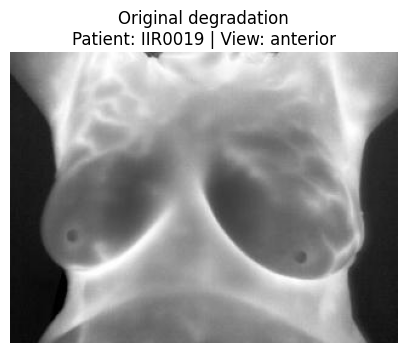

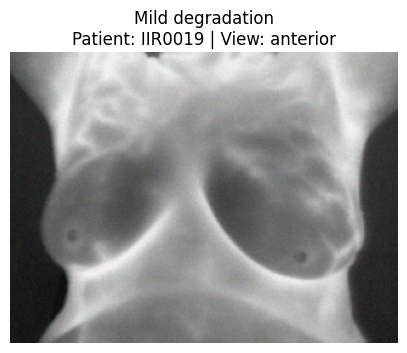

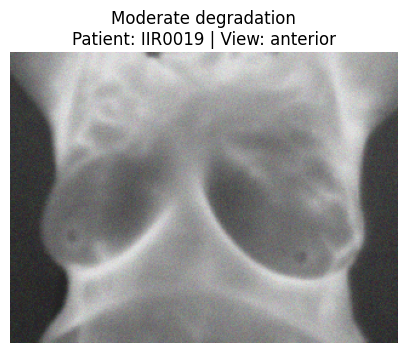

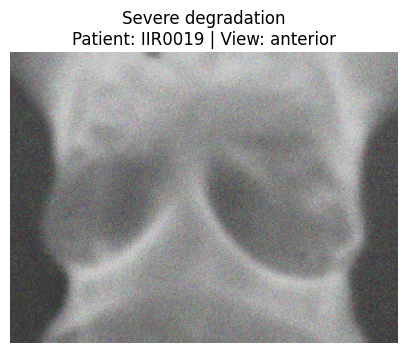

In [44]:
import matplotlib.pyplot as plt

# Pick one malignant test image
sample_row = df[
    (df["split"] == "test") &
    (df["diagnosis"] == "Malignant")
].iloc[0]

sample_path = sample_row["filepath"]

original = Image.open(sample_path).convert("RGB")

levels = ["original", "mild", "moderate", "severe"]

for level in levels:

    # Reset seed so comparison is reproducible
    np.random.seed(42)

    img = degrade_image(original, level)

    plt.figure(figsize=(5, 5))
    plt.imshow(img)
    plt.title(
        f"{level.capitalize()} degradation\n"
        f"Patient: {sample_row['patient_id']} | "
        f"View: {sample_row['view']}"
    )
    plt.axis("off")
    plt.show()

In [45]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
import numpy as np
import pandas as pd

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

IMG_SIZE = 224
BATCH_SIZE = 16

# ImageNet normalization because we will use pretrained networks
normalize = transforms.Normalize(
    mean=[0.485, 0.456, 0.406],
    std=[0.229, 0.224, 0.225]
)

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),

    # Conservative augmentation
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(5),

    transforms.ToTensor(),
    normalize
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    normalize
])

print("Image size:", IMG_SIZE)
print("Batch size:", BATCH_SIZE)

Device: cuda
Image size: 224
Batch size: 16


In [46]:
class BreastThermographyDataset(Dataset):

    def __init__(
        self,
        dataframe,
        transform=None,
        degradation="original",
        seed=42
    ):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform
        self.degradation = degradation
        self.seed = seed

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        image = Image.open(row["filepath"]).convert("RGB")

        # Make degradation deterministic for each image
        if self.degradation != "original":

            state = np.random.get_state()

            np.random.seed(self.seed + idx)

            image = degrade_image(
                image,
                self.degradation
            )

            np.random.set_state(state)

        if self.transform:
            image = self.transform(image)

        label = int(row["label"])

        return image, label

In [47]:
train_df = df[df["split"] == "train"].reset_index(drop=True)
val_df   = df[df["split"] == "val"].reset_index(drop=True)
test_df  = df[df["split"] == "test"].reset_index(drop=True)

print("Train images:", len(train_df))
print("Validation images:", len(val_df))
print("Test images:", len(test_df))

print("\nTrain:")
print(train_df["diagnosis"].value_counts())

print("\nValidation:")
print(val_df["diagnosis"].value_counts())

print("\nTest:")
print(test_df["diagnosis"].value_counts())

Train images: 249
Validation images: 54
Test images: 54

Train:
diagnosis
Benign       177
Malignant     72
Name: count, dtype: int64

Validation:
diagnosis
Benign       36
Malignant    18
Name: count, dtype: int64

Test:
diagnosis
Benign       39
Malignant    15
Name: count, dtype: int64


In [48]:
train_dataset = BreastThermographyDataset(
    train_df,
    transform=train_transform,
    degradation="original"
)

val_dataset = BreastThermographyDataset(
    val_df,
    transform=eval_transform,
    degradation="original"
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))

Train batches: 16
Validation batches: 4


In [49]:
images, labels = next(iter(train_loader))

print("Image batch:", images.shape)
print("Label batch:", labels.shape)
print("Labels:", labels)
print("Min:", images.min().item())
print("Max:", images.max().item())

Image batch: torch.Size([16, 3, 224, 224])
Label batch: torch.Size([16])
Labels: tensor([1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0])
Min: -2.1179039478302
Max: 2.640000104904175


In [50]:
import numpy as np
import torch
import torch.nn as nn

class_counts = train_df["label"].value_counts().sort_index()

print("Class counts:")
print(class_counts)

n_total = len(train_df)
n_classes = 2

class_weights = []

for count in class_counts:
    weight = n_total / (n_classes * count)
    class_weights.append(weight)

class_weights = torch.tensor(
    class_weights,
    dtype=torch.float32
).to(DEVICE)

print("\nClass weights:", class_weights)

criterion = nn.CrossEntropyLoss(
    weight=class_weights
)

Class counts:
label
0    177
1     72
Name: count, dtype: int64

Class weights: tensor([0.7034, 1.7292], device='cuda:0')


In [51]:
from torchvision.models import resnet18, ResNet18_Weights

weights = ResNet18_Weights.DEFAULT

model = resnet18(weights=weights)

# Replace final classifier
num_features = model.fc.in_features

model.fc = nn.Sequential(
    nn.Dropout(p=0.30),
    nn.Linear(num_features, 2)
)

model = model.to(DEVICE)

print(model.fc)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 130MB/s]


Sequential(
  (0): Dropout(p=0.3, inplace=False)
  (1): Linear(in_features=512, out_features=2, bias=True)
)


In [52]:
import torch.optim as optim

optimizer = optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2
)

print("Optimizer ready.")

Optimizer ready.


In [53]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

def run_epoch(
    model,
    loader,
    criterion,
    optimizer=None
):

    training = optimizer is not None

    if training:
        model.train()
    else:
        model.eval()

    running_loss = 0.0

    all_labels = []
    all_preds = []
    all_probs = []

    for images, labels in loader:

        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        if training:
            optimizer.zero_grad()

        with torch.set_grad_enabled(training):

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

            probs = torch.softmax(
                outputs,
                dim=1
            )[:, 1]

            preds = torch.argmax(
                outputs,
                dim=1
            )

            if training:
                loss.backward()
                optimizer.step()

        running_loss += (
            loss.item() * images.size(0)
        )

        all_labels.extend(
            labels.detach().cpu().numpy()
        )

        all_preds.extend(
            preds.detach().cpu().numpy()
        )

        all_probs.extend(
            probs.detach().cpu().numpy()
        )

    epoch_loss = (
        running_loss / len(loader.dataset)
    )

    accuracy = accuracy_score(
        all_labels,
        all_preds
    )

    precision = precision_score(
        all_labels,
        all_preds,
        zero_division=0
    )

    recall = recall_score(
        all_labels,
        all_preds,
        zero_division=0
    )

    f1 = f1_score(
        all_labels,
        all_preds,
        zero_division=0
    )

    try:
        auc = roc_auc_score(
            all_labels,
            all_probs
        )
    except:
        auc = np.nan

    return {
        "loss": epoch_loss,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "auc": auc
    }

In [54]:
import copy
import pandas as pd
from pathlib import Path

EPOCHS = 20
EARLY_STOP_PATIENCE = 5

best_val_loss = float("inf")
best_epoch = 0
patience_counter = 0

history = []

BEST_MODEL_PATH = (
    MODELS_DIR /
    "resnet18_original_best.pt"
)

for epoch in range(1, EPOCHS + 1):

    train_metrics = run_epoch(
        model,
        train_loader,
        criterion,
        optimizer
    )

    val_metrics = run_epoch(
        model,
        val_loader,
        criterion
    )

    scheduler.step(
        val_metrics["loss"]
    )

    history.append({
        "epoch": epoch,

        "train_loss":
            train_metrics["loss"],

        "train_acc":
            train_metrics["accuracy"],

        "train_f1":
            train_metrics["f1"],

        "train_auc":
            train_metrics["auc"],

        "val_loss":
            val_metrics["loss"],

        "val_acc":
            val_metrics["accuracy"],

        "val_f1":
            val_metrics["f1"],

        "val_auc":
            val_metrics["auc"]
    })

    print(
        f"Epoch {epoch:02d} | "
        f"Train Loss {train_metrics['loss']:.4f} | "
        f"Train Acc {train_metrics['accuracy']:.3f} | "
        f"Train AUC {train_metrics['auc']:.3f} || "
        f"Val Loss {val_metrics['loss']:.4f} | "
        f"Val Acc {val_metrics['accuracy']:.3f} | "
        f"Val F1 {val_metrics['f1']:.3f} | "
        f"Val AUC {val_metrics['auc']:.3f}"
    )

    # Save according to validation loss only
    if val_metrics["loss"] < best_val_loss:

        best_val_loss = val_metrics["loss"]
        best_epoch = epoch
        patience_counter = 0

        torch.save(
            model.state_dict(),
            BEST_MODEL_PATH
        )

        print("   -> Best model saved")

    else:

        patience_counter += 1

    if patience_counter >= EARLY_STOP_PATIENCE:

        print(
            f"\nEarly stopping at epoch {epoch}"
        )

        break

history_df = pd.DataFrame(history)

history_path = (
    RESULTS_DIR /
    "resnet18_training_history.csv"
)

history_df.to_csv(
    history_path,
    index=False
)

print("\nBest epoch:", best_epoch)
print("Best validation loss:", best_val_loss)
print("Model saved:", BEST_MODEL_PATH)
print("History saved:", history_path)

Epoch 01 | Train Loss 0.7189 | Train Acc 0.510 | Train AUC 0.615 || Val Loss 0.6268 | Val Acc 0.611 | Val F1 0.512 | Val AUC 0.699
   -> Best model saved
Epoch 02 | Train Loss 0.4660 | Train Acc 0.811 | Train AUC 0.867 || Val Loss 0.7909 | Val Acc 0.722 | Val F1 0.286 | Val AUC 0.596
Epoch 03 | Train Loss 0.3026 | Train Acc 0.876 | Train AUC 0.952 || Val Loss 0.8283 | Val Acc 0.704 | Val F1 0.429 | Val AUC 0.545
Epoch 04 | Train Loss 0.1745 | Train Acc 0.932 | Train AUC 0.988 || Val Loss 1.0478 | Val Acc 0.704 | Val F1 0.385 | Val AUC 0.520
Epoch 05 | Train Loss 0.1591 | Train Acc 0.952 | Train AUC 0.988 || Val Loss 1.0465 | Val Acc 0.593 | Val F1 0.421 | Val AUC 0.529
Epoch 06 | Train Loss 0.0894 | Train Acc 0.972 | Train AUC 0.998 || Val Loss 0.9333 | Val Acc 0.685 | Val F1 0.452 | Val AUC 0.590

Early stopping at epoch 6

Best epoch: 1
Best validation loss: 0.6267551901163878
Model saved: /content/drive/MyDrive/ICVGIP_Breast_Thermography/models/resnet18_original_best.pt
History save

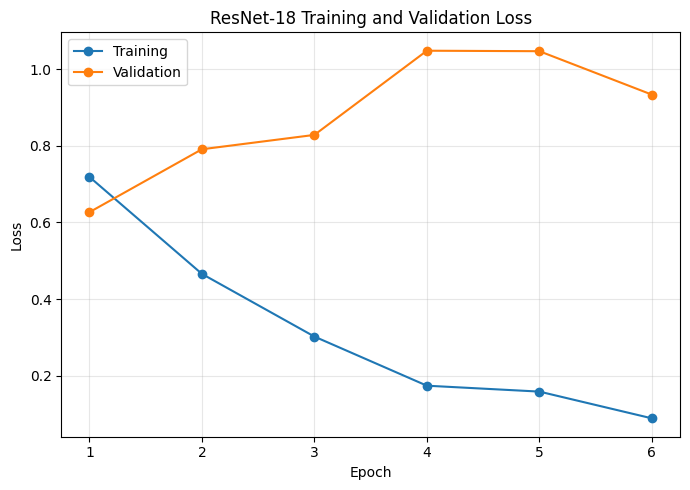

In [55]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

plt.plot(
    history_df["epoch"],
    history_df["train_loss"],
    marker="o",
    label="Training"
)

plt.plot(
    history_df["epoch"],
    history_df["val_loss"],
    marker="o",
    label="Validation"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ResNet-18 Training and Validation Loss")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

loss_fig = (
    FIGURES_DIR /
    "resnet18_loss_curve.png"
)

plt.savefig(
    loss_fig,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

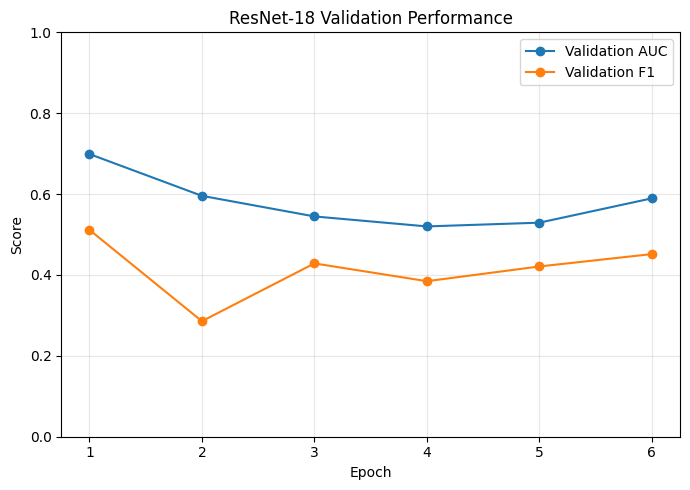

In [56]:
plt.figure(figsize=(7, 5))

plt.plot(
    history_df["epoch"],
    history_df["val_auc"],
    marker="o",
    label="Validation AUC"
)

plt.plot(
    history_df["epoch"],
    history_df["val_f1"],
    marker="o",
    label="Validation F1"
)

plt.xlabel("Epoch")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.title("ResNet-18 Validation Performance")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

perf_fig = (
    FIGURES_DIR /
    "resnet18_validation_performance.png"
)

plt.savefig(
    perf_fig,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [57]:
import torch
import torch.nn as nn
from torchvision.models import resnet18, ResNet18_Weights

weights = ResNet18_Weights.DEFAULT

model = resnet18(weights=weights)

# Freeze ALL pretrained layers
for param in model.parameters():
    param.requires_grad = False

# Replace classifier
num_features = model.fc.in_features

model.fc = nn.Sequential(
    nn.Dropout(p=0.5),
    nn.Linear(num_features, 128),
    nn.ReLU(),
    nn.Dropout(p=0.3),
    nn.Linear(128, 2)
)

model = model.to(DEVICE)

# Confirm trainable parameters
trainable = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

total = sum(
    p.numel()
    for p in model.parameters()
)

print("Total parameters:", total)
print("Trainable parameters:", trainable)
print(model.fc)

Total parameters: 11242434
Trainable parameters: 65922
Sequential(
  (0): Dropout(p=0.5, inplace=False)
  (1): Linear(in_features=512, out_features=128, bias=True)
  (2): ReLU()
  (3): Dropout(p=0.3, inplace=False)
  (4): Linear(in_features=128, out_features=2, bias=True)
)


In [58]:
import torch.optim as optim

optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=3e-4,
    weight_decay=1e-3
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2
)

print("Frozen-backbone optimizer ready.")

Frozen-backbone optimizer ready.


In [59]:
criterion = nn.CrossEntropyLoss(
    weight=class_weights
)

In [60]:
EPOCHS = 15
EARLY_STOP_PATIENCE = 4

best_val_loss = float("inf")
best_epoch = 0
patience_counter = 0

history_frozen = []

BEST_MODEL_PATH_FROZEN = (
    MODELS_DIR /
    "resnet18_frozen_best.pt"
)

for epoch in range(1, EPOCHS + 1):

    train_metrics = run_epoch(
        model,
        train_loader,
        criterion,
        optimizer
    )

    val_metrics = run_epoch(
        model,
        val_loader,
        criterion
    )

    scheduler.step(
        val_metrics["loss"]
    )

    history_frozen.append({
        "epoch": epoch,
        "train_loss": train_metrics["loss"],
        "train_acc": train_metrics["accuracy"],
        "train_f1": train_metrics["f1"],
        "train_auc": train_metrics["auc"],
        "val_loss": val_metrics["loss"],
        "val_acc": val_metrics["accuracy"],
        "val_f1": val_metrics["f1"],
        "val_auc": val_metrics["auc"]
    })

    print(
        f"Epoch {epoch:02d} | "
        f"Train Loss {train_metrics['loss']:.4f} | "
        f"Train Acc {train_metrics['accuracy']:.3f} | "
        f"Train AUC {train_metrics['auc']:.3f} || "
        f"Val Loss {val_metrics['loss']:.4f} | "
        f"Val Acc {val_metrics['accuracy']:.3f} | "
        f"Val F1 {val_metrics['f1']:.3f} | "
        f"Val AUC {val_metrics['auc']:.3f}"
    )

    if val_metrics["loss"] < best_val_loss:

        best_val_loss = val_metrics["loss"]
        best_epoch = epoch
        patience_counter = 0

        torch.save(
            model.state_dict(),
            BEST_MODEL_PATH_FROZEN
        )

        print("   -> Best model saved")

    else:
        patience_counter += 1

    if patience_counter >= EARLY_STOP_PATIENCE:
        print(f"\nEarly stopping at epoch {epoch}")
        break

history_frozen_df = pd.DataFrame(history_frozen)

history_frozen_df.to_csv(
    RESULTS_DIR / "resnet18_frozen_history.csv",
    index=False
)

print("\nBest epoch:", best_epoch)
print("Best validation loss:", best_val_loss)
print("Saved:", BEST_MODEL_PATH_FROZEN)

Epoch 01 | Train Loss 0.7180 | Train Acc 0.518 | Train AUC 0.497 || Val Loss 0.6658 | Val Acc 0.667 | Val F1 0.000 | Val AUC 0.511
   -> Best model saved
Epoch 02 | Train Loss 0.7160 | Train Acc 0.518 | Train AUC 0.508 || Val Loss 0.6656 | Val Acc 0.648 | Val F1 0.000 | Val AUC 0.522
   -> Best model saved
Epoch 03 | Train Loss 0.6847 | Train Acc 0.586 | Train AUC 0.594 || Val Loss 0.6913 | Val Acc 0.500 | Val F1 0.341 | Val AUC 0.478
Epoch 04 | Train Loss 0.6788 | Train Acc 0.582 | Train AUC 0.612 || Val Loss 0.7073 | Val Acc 0.463 | Val F1 0.431 | Val AUC 0.500
Epoch 05 | Train Loss 0.6775 | Train Acc 0.618 | Train AUC 0.611 || Val Loss 0.6966 | Val Acc 0.481 | Val F1 0.417 | Val AUC 0.512
Epoch 06 | Train Loss 0.6557 | Train Acc 0.614 | Train AUC 0.668 || Val Loss 0.7000 | Val Acc 0.500 | Val F1 0.426 | Val AUC 0.517

Early stopping at epoch 6

Best epoch: 2
Best validation loss: 0.6655517529558252
Saved: /content/drive/MyDrive/ICVGIP_Breast_Thermography/models/resnet18_frozen_best.

In [61]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

def predict_with_metadata(model, dataframe, degradation="original"):

    dataset = BreastThermographyDataset(
        dataframe,
        transform=eval_transform,
        degradation=degradation
    )

    loader = DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=2
    )

    model.eval()

    probabilities = []

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(DEVICE)

            outputs = model(images)

            probs = torch.softmax(
                outputs,
                dim=1
            )[:, 1]

            probabilities.extend(
                probs.cpu().numpy()
            )

    results = dataframe.copy().reset_index(drop=True)

    results["prob_malignant"] = probabilities

    return results

In [62]:
model.load_state_dict(
    torch.load(
        BEST_MODEL_PATH_FROZEN,
        map_location=DEVICE
    )
)

val_predictions = predict_with_metadata(
    model,
    val_df,
    degradation="original"
)

In [63]:
patient_val = (
    val_predictions
    .groupby(
        ["patient_id", "label"],
        as_index=False
    )
    ["prob_malignant"]
    .mean()
)

patient_val["prediction"] = (
    patient_val["prob_malignant"] >= 0.5
).astype(int)

y_true = patient_val["label"]
y_pred = patient_val["prediction"]
y_prob = patient_val["prob_malignant"]

print("PATIENT-LEVEL VALIDATION RESULTS")
print("--------------------------------")

print(
    "Accuracy:",
    round(accuracy_score(y_true, y_pred), 3)
)

print(
    "Sensitivity:",
    round(recall_score(y_true, y_pred), 3)
)

tn, fp, fn, tp = confusion_matrix(
    y_true,
    y_pred
).ravel()

specificity = tn / (tn + fp)

print(
    "Specificity:",
    round(specificity, 3)
)

print(
    "Precision:",
    round(
        precision_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        3
    )
)

print(
    "F1:",
    round(
        f1_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        3
    )
)

print(
    "ROC-AUC:",
    round(
        roc_auc_score(
            y_true,
            y_prob
        ),
        3
    )
)

print("\nConfusion matrix:")
print(
    confusion_matrix(
        y_true,
        y_pred
    )
)

PATIENT-LEVEL VALIDATION RESULTS
--------------------------------
Accuracy: 0.667
Sensitivity: 0.0
Specificity: 1.0
Precision: 0.0
F1: 0.0
ROC-AUC: 0.542

Confusion matrix:
[[12  0]
 [ 6  0]]


In [64]:
import torch
import torch.nn as nn
from torchvision.models import resnet18, ResNet18_Weights

# Recreate architecture used in first experiment
model_full = resnet18(weights=None)

num_features = model_full.fc.in_features

model_full.fc = nn.Sequential(
    nn.Dropout(p=0.30),
    nn.Linear(num_features, 2)
)

model_full = model_full.to(DEVICE)

FULL_MODEL_PATH = MODELS_DIR / "resnet18_original_best.pt"

model_full.load_state_dict(
    torch.load(
        FULL_MODEL_PATH,
        map_location=DEVICE
    )
)

model_full.eval()

print("Full fine-tuned best checkpoint loaded.")

Full fine-tuned best checkpoint loaded.


In [65]:
val_predictions_full = predict_with_metadata(
    model_full,
    val_df,
    degradation="original"
)

patient_val_full = (
    val_predictions_full
    .groupby(
        ["patient_id", "label"],
        as_index=False
    )["prob_malignant"]
    .mean()
)

patient_val_full["prediction"] = (
    patient_val_full["prob_malignant"] >= 0.5
).astype(int)

y_true = patient_val_full["label"]
y_pred = patient_val_full["prediction"]
y_prob = patient_val_full["prob_malignant"]

tn, fp, fn, tp = confusion_matrix(
    y_true,
    y_pred
).ravel()

specificity = tn / (tn + fp)

print("PATIENT-LEVEL RESULTS — FIRST FULL FINE-TUNING")
print("------------------------------------------------")

print("Accuracy:",
      round(accuracy_score(y_true, y_pred), 3))

print("Sensitivity:",
      round(recall_score(y_true, y_pred), 3))

print("Specificity:",
      round(specificity, 3))

print("Precision:",
      round(precision_score(
          y_true,
          y_pred,
          zero_division=0
      ), 3))

print("F1:",
      round(f1_score(
          y_true,
          y_pred,
          zero_division=0
      ), 3))

print("ROC-AUC:",
      round(roc_auc_score(
          y_true,
          y_prob
      ), 3))

print("\nConfusion matrix:")
print(confusion_matrix(y_true, y_pred))

PATIENT-LEVEL RESULTS — FIRST FULL FINE-TUNING
------------------------------------------------
Accuracy: 0.667
Sensitivity: 0.667
Specificity: 0.667
Precision: 0.5
F1: 0.571
ROC-AUC: 0.75

Confusion matrix:
[[8 4]
 [2 4]]


In [66]:
from torchvision.models import resnet18, ResNet18_Weights

model_partial = resnet18(
    weights=ResNet18_Weights.DEFAULT
)

# Freeze everything first
for param in model_partial.parameters():
    param.requires_grad = False

# Unfreeze final residual block
for param in model_partial.layer4.parameters():
    param.requires_grad = True

# New classification head
num_features = model_partial.fc.in_features

model_partial.fc = nn.Sequential(
    nn.Dropout(p=0.5),
    nn.Linear(num_features, 128),
    nn.ReLU(),
    nn.Dropout(p=0.3),
    nn.Linear(128, 2)
)

# New head is trainable automatically
model_partial = model_partial.to(DEVICE)

trainable = sum(
    p.numel()
    for p in model_partial.parameters()
    if p.requires_grad
)

total = sum(
    p.numel()
    for p in model_partial.parameters()
)

print("Total parameters:", total)
print("Trainable parameters:", trainable)
print("Percentage trainable:",
      round(100 * trainable / total, 2), "%")

Total parameters: 11242434
Trainable parameters: 8459650
Percentage trainable: 75.25 %


In [67]:
optimizer = torch.optim.AdamW(
    [
        {
            "params": model_partial.layer4.parameters(),
            "lr": 1e-5
        },
        {
            "params": model_partial.fc.parameters(),
            "lr": 2e-4
        }
    ],
    weight_decay=1e-3
)

criterion = nn.CrossEntropyLoss(
    weight=class_weights
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2
)

print("Partial fine-tuning optimizer ready.")

Partial fine-tuning optimizer ready.


In [68]:
def patient_level_auc(model, dataframe):

    preds = predict_with_metadata(
        model,
        dataframe,
        degradation="original"
    )

    patient_preds = (
        preds.groupby(
            ["patient_id", "label"],
            as_index=False
        )["prob_malignant"]
        .mean()
    )

    auc = roc_auc_score(
        patient_preds["label"],
        patient_preds["prob_malignant"]
    )

    return auc

In [69]:
EPOCHS = 15
PATIENCE = 5

best_patient_auc = -1
best_epoch = 0
patience_counter = 0

history_partial = []

PARTIAL_MODEL_PATH = (
    MODELS_DIR /
    "resnet18_partial_best.pt"
)

for epoch in range(1, EPOCHS + 1):

    train_metrics = run_epoch(
        model_partial,
        train_loader,
        criterion,
        optimizer
    )

    val_metrics = run_epoch(
        model_partial,
        val_loader,
        criterion
    )

    scheduler.step(
        val_metrics["loss"]
    )

    p_auc = patient_level_auc(
        model_partial,
        val_df
    )

    history_partial.append({
        "epoch": epoch,
        "train_loss": train_metrics["loss"],
        "train_auc": train_metrics["auc"],
        "val_loss": val_metrics["loss"],
        "val_acc": val_metrics["accuracy"],
        "val_f1": val_metrics["f1"],
        "image_val_auc": val_metrics["auc"],
        "patient_val_auc": p_auc
    })

    print(
        f"Epoch {epoch:02d} | "
        f"Train Loss {train_metrics['loss']:.4f} | "
        f"Train AUC {train_metrics['auc']:.3f} || "
        f"Val Loss {val_metrics['loss']:.4f} | "
        f"Val Acc {val_metrics['accuracy']:.3f} | "
        f"Val F1 {val_metrics['f1']:.3f} | "
        f"Image AUC {val_metrics['auc']:.3f} | "
        f"Patient AUC {p_auc:.3f}"
    )

    if p_auc > best_patient_auc:

        best_patient_auc = p_auc
        best_epoch = epoch
        patience_counter = 0

        torch.save(
            model_partial.state_dict(),
            PARTIAL_MODEL_PATH
        )

        print("   -> Best patient-level model saved")

    else:
        patience_counter += 1

    if patience_counter >= PATIENCE:
        print(
            f"\nEarly stopping at epoch {epoch}"
        )
        break

history_partial_df = pd.DataFrame(
    history_partial
)

history_partial_df.to_csv(
    RESULTS_DIR /
    "resnet18_partial_history.csv",
    index=False
)

print("\nBest epoch:", best_epoch)
print(
    "Best patient-level validation AUC:",
    round(best_patient_auc, 3)
)

Epoch 01 | Train Loss 0.6909 | Train AUC 0.589 || Val Loss 0.6739 | Val Acc 0.722 | Val F1 0.615 | Image AUC 0.657 | Patient AUC 0.736
   -> Best patient-level model saved
Epoch 02 | Train Loss 0.7032 | Train AUC 0.538 || Val Loss 0.6456 | Val Acc 0.648 | Val F1 0.000 | Image AUC 0.631 | Patient AUC 0.708
Epoch 03 | Train Loss 0.6467 | Train AUC 0.664 || Val Loss 0.6812 | Val Acc 0.611 | Val F1 0.512 | Image AUC 0.591 | Patient AUC 0.611
Epoch 04 | Train Loss 0.6706 | Train AUC 0.628 || Val Loss 0.7047 | Val Acc 0.556 | Val F1 0.333 | Image AUC 0.495 | Patient AUC 0.472
Epoch 05 | Train Loss 0.6614 | Train AUC 0.636 || Val Loss 0.7492 | Val Acc 0.500 | Val F1 0.400 | Image AUC 0.469 | Patient AUC 0.458
Epoch 06 | Train Loss 0.6388 | Train AUC 0.676 || Val Loss 0.7424 | Val Acc 0.500 | Val F1 0.372 | Image AUC 0.472 | Patient AUC 0.458

Early stopping at epoch 6

Best epoch: 1
Best patient-level validation AUC: 0.736


In [70]:
import torch
import torch.nn as nn

from torchvision.models import (
    mobilenet_v3_small,
    MobileNet_V3_Small_Weights
)

mobile_model = mobilenet_v3_small(
    weights=MobileNet_V3_Small_Weights.DEFAULT
)

print(mobile_model.classifier)

Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 128MB/s]

Sequential(
  (0): Linear(in_features=576, out_features=1024, bias=True)
  (1): Hardswish()
  (2): Dropout(p=0.2, inplace=True)
  (3): Linear(in_features=1024, out_features=1000, bias=True)
)


In [71]:
in_features = mobile_model.classifier[3].in_features

mobile_model.classifier[3] = nn.Sequential(
    nn.Dropout(p=0.30),
    nn.Linear(in_features, 2)
)

mobile_model = mobile_model.to(DEVICE)

total_params = sum(
    p.numel()
    for p in mobile_model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in mobile_model.parameters()
    if p.requires_grad
)

print("Total parameters:", total_params)
print("Trainable parameters:", trainable_params)
print(mobile_model.classifier)

Total parameters: 1519906
Trainable parameters: 1519906
Sequential(
  (0): Linear(in_features=576, out_features=1024, bias=True)
  (1): Hardswish()
  (2): Dropout(p=0.2, inplace=True)
  (3): Sequential(
    (0): Dropout(p=0.3, inplace=False)
    (1): Linear(in_features=1024, out_features=2, bias=True)
  )
)


In [72]:
optimizer_mobile = torch.optim.AdamW(
    mobile_model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

scheduler_mobile = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_mobile,
    mode="min",
    factor=0.5,
    patience=2
)

criterion = nn.CrossEntropyLoss(
    weight=class_weights
)

print("MobileNet optimizer ready.")

MobileNet optimizer ready.


In [73]:
EPOCHS = 20
EARLY_STOP_PATIENCE = 5

best_val_loss = float("inf")
best_epoch = 0
patience_counter = 0

mobile_history = []

MOBILE_MODEL_PATH = (
    MODELS_DIR /
    "mobilenetv3_original_best.pt"
)

for epoch in range(1, EPOCHS + 1):

    train_metrics = run_epoch(
        mobile_model,
        train_loader,
        criterion,
        optimizer_mobile
    )

    val_metrics = run_epoch(
        mobile_model,
        val_loader,
        criterion
    )

    scheduler_mobile.step(
        val_metrics["loss"]
    )

    # Patient-level AUC only for reporting,
    # NOT for selecting checkpoint
    p_auc = patient_level_auc(
        mobile_model,
        val_df
    )

    mobile_history.append({
        "epoch": epoch,
        "train_loss": train_metrics["loss"],
        "train_acc": train_metrics["accuracy"],
        "train_f1": train_metrics["f1"],
        "train_auc": train_metrics["auc"],

        "val_loss": val_metrics["loss"],
        "val_acc": val_metrics["accuracy"],
        "val_f1": val_metrics["f1"],
        "image_val_auc": val_metrics["auc"],
        "patient_val_auc": p_auc
    })

    print(
        f"Epoch {epoch:02d} | "
        f"Train Loss {train_metrics['loss']:.4f} | "
        f"Train Acc {train_metrics['accuracy']:.3f} | "
        f"Train AUC {train_metrics['auc']:.3f} || "
        f"Val Loss {val_metrics['loss']:.4f} | "
        f"Val Acc {val_metrics['accuracy']:.3f} | "
        f"Val F1 {val_metrics['f1']:.3f} | "
        f"Image AUC {val_metrics['auc']:.3f} | "
        f"Patient AUC {p_auc:.3f}"
    )

    # Same checkpoint rule as original ResNet:
    # lowest validation loss
    if val_metrics["loss"] < best_val_loss:

        best_val_loss = val_metrics["loss"]
        best_epoch = epoch
        patience_counter = 0

        torch.save(
            mobile_model.state_dict(),
            MOBILE_MODEL_PATH
        )

        print("   -> Best model saved")

    else:
        patience_counter += 1

    if patience_counter >= EARLY_STOP_PATIENCE:

        print(
            f"\nEarly stopping at epoch {epoch}"
        )
        break


mobile_history_df = pd.DataFrame(
    mobile_history
)

mobile_history_df.to_csv(
    RESULTS_DIR /
    "mobilenetv3_training_history.csv",
    index=False
)

print("\nBest epoch:", best_epoch)
print("Best validation loss:", best_val_loss)
print("Saved:", MOBILE_MODEL_PATH)

Epoch 01 | Train Loss 0.6837 | Train Acc 0.570 | Train AUC 0.598 || Val Loss 0.6911 | Val Acc 0.685 | Val F1 0.190 | Image AUC 0.427 | Patient AUC 0.417
   -> Best model saved
Epoch 02 | Train Loss 0.6188 | Train Acc 0.715 | Train AUC 0.731 || Val Loss 0.6904 | Val Acc 0.667 | Val F1 0.100 | Image AUC 0.454 | Patient AUC 0.486
   -> Best model saved
Epoch 03 | Train Loss 0.5651 | Train Acc 0.747 | Train AUC 0.820 || Val Loss 0.6993 | Val Acc 0.630 | Val F1 0.091 | Image AUC 0.469 | Patient AUC 0.500
Epoch 04 | Train Loss 0.5471 | Train Acc 0.763 | Train AUC 0.830 || Val Loss 0.6963 | Val Acc 0.630 | Val F1 0.091 | Image AUC 0.529 | Patient AUC 0.542
Epoch 05 | Train Loss 0.4647 | Train Acc 0.823 | Train AUC 0.898 || Val Loss 0.6730 | Val Acc 0.630 | Val F1 0.231 | Image AUC 0.577 | Patient AUC 0.569
   -> Best model saved
Epoch 06 | Train Loss 0.4417 | Train Acc 0.787 | Train AUC 0.889 || Val Loss 0.6650 | Val Acc 0.667 | Val F1 0.308 | Image AUC 0.627 | Patient AUC 0.583
   -> Best mo

In [74]:
mobile_model.load_state_dict(
    torch.load(
        MOBILE_MODEL_PATH,
        map_location=DEVICE
    )
)

mobile_model.eval()

mobile_val_predictions = predict_with_metadata(
    mobile_model,
    val_df,
    degradation="original"
)

mobile_patient_val = (
    mobile_val_predictions
    .groupby(
        ["patient_id", "label"],
        as_index=False
    )["prob_malignant"]
    .mean()
)

mobile_patient_val["prediction"] = (
    mobile_patient_val["prob_malignant"] >= 0.5
).astype(int)

y_true = mobile_patient_val["label"]
y_pred = mobile_patient_val["prediction"]
y_prob = mobile_patient_val["prob_malignant"]

tn, fp, fn, tp = confusion_matrix(
    y_true,
    y_pred
).ravel()

specificity = tn / (tn + fp)

print("MOBILENETV3 — PATIENT-LEVEL VALIDATION")
print("--------------------------------------")

print("Accuracy:",
      round(accuracy_score(y_true, y_pred), 3))

print("Sensitivity:",
      round(recall_score(y_true, y_pred), 3))

print("Specificity:",
      round(specificity, 3))

print("Precision:",
      round(
          precision_score(
              y_true,
              y_pred,
              zero_division=0
          ), 3
      ))

print("F1:",
      round(
          f1_score(
              y_true,
              y_pred,
              zero_division=0
          ), 3
      ))

print("ROC-AUC:",
      round(
          roc_auc_score(
              y_true,
              y_prob
          ), 3
      ))

print("\nConfusion matrix:")
print(
    confusion_matrix(
        y_true,
        y_pred
    )
)

MOBILENETV3 — PATIENT-LEVEL VALIDATION
--------------------------------------
Accuracy: 0.722
Sensitivity: 0.333
Specificity: 0.917
Precision: 0.667
F1: 0.444
ROC-AUC: 0.583

Confusion matrix:
[[11  1]
 [ 4  2]]


In [75]:
import torch
import torch.nn as nn
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

eff_model = efficientnet_b0(
    weights=EfficientNet_B0_Weights.DEFAULT
)

print(eff_model.classifier)

in_features = eff_model.classifier[1].in_features

eff_model.classifier[1] = nn.Sequential(
    nn.Dropout(p=0.30),
    nn.Linear(in_features, 2)
)

eff_model = eff_model.to(DEVICE)

total_params = sum(p.numel() for p in eff_model.parameters())
trainable_params = sum(p.numel() for p in eff_model.parameters() if p.requires_grad)

print("Total parameters:", total_params)
print("Trainable parameters:", trainable_params)
print(eff_model.classifier)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 150MB/s]

Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=1000, bias=True)
)
Total parameters: 4010110
Trainable parameters: 4010110
Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Sequential(
    (0): Dropout(p=0.3, inplace=False)
    (1): Linear(in_features=1280, out_features=2, bias=True)
  )
)


In [76]:
optimizer_eff = torch.optim.AdamW(
    eff_model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

scheduler_eff = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_eff,
    mode="min",
    factor=0.5,
    patience=2
)

criterion = nn.CrossEntropyLoss(
    weight=class_weights
)

print("EfficientNet optimizer ready.")

EfficientNet optimizer ready.


In [77]:
EPOCHS = 20
EARLY_STOP_PATIENCE = 5

best_val_loss = float("inf")
best_epoch = 0
patience_counter = 0

eff_history = []

EFF_MODEL_PATH = (
    MODELS_DIR /
    "efficientnetb0_original_best.pt"
)

for epoch in range(1, EPOCHS + 1):

    train_metrics = run_epoch(
        eff_model,
        train_loader,
        criterion,
        optimizer_eff
    )

    val_metrics = run_epoch(
        eff_model,
        val_loader,
        criterion
    )

    scheduler_eff.step(
        val_metrics["loss"]
    )

    p_auc = patient_level_auc(
        eff_model,
        val_df
    )

    eff_history.append({
        "epoch": epoch,
        "train_loss": train_metrics["loss"],
        "train_acc": train_metrics["accuracy"],
        "train_f1": train_metrics["f1"],
        "train_auc": train_metrics["auc"],
        "val_loss": val_metrics["loss"],
        "val_acc": val_metrics["accuracy"],
        "val_f1": val_metrics["f1"],
        "image_val_auc": val_metrics["auc"],
        "patient_val_auc": p_auc
    })

    print(
        f"Epoch {epoch:02d} | "
        f"Train Loss {train_metrics['loss']:.4f} | "
        f"Train Acc {train_metrics['accuracy']:.3f} | "
        f"Train AUC {train_metrics['auc']:.3f} || "
        f"Val Loss {val_metrics['loss']:.4f} | "
        f"Val Acc {val_metrics['accuracy']:.3f} | "
        f"Val F1 {val_metrics['f1']:.3f} | "
        f"Image AUC {val_metrics['auc']:.3f} | "
        f"Patient AUC {p_auc:.3f}"
    )

    if val_metrics["loss"] < best_val_loss:

        best_val_loss = val_metrics["loss"]
        best_epoch = epoch
        patience_counter = 0

        torch.save(
            eff_model.state_dict(),
            EFF_MODEL_PATH
        )

        print("   -> Best model saved")

    else:
        patience_counter += 1

    if patience_counter >= EARLY_STOP_PATIENCE:
        print(f"\nEarly stopping at epoch {epoch}")
        break

eff_history_df = pd.DataFrame(eff_history)

eff_history_df.to_csv(
    RESULTS_DIR / "efficientnetb0_training_history.csv",
    index=False
)

print("\nBest epoch:", best_epoch)
print("Best validation loss:", best_val_loss)
print("Saved:", EFF_MODEL_PATH)

Epoch 01 | Train Loss 0.6833 | Train Acc 0.550 | Train AUC 0.596 || Val Loss 0.7007 | Val Acc 0.537 | Val F1 0.194 | Image AUC 0.432 | Patient AUC 0.319
   -> Best model saved
Epoch 02 | Train Loss 0.6107 | Train Acc 0.679 | Train AUC 0.767 || Val Loss 0.7386 | Val Acc 0.519 | Val F1 0.381 | Image AUC 0.463 | Patient AUC 0.431
Epoch 03 | Train Loss 0.5426 | Train Acc 0.763 | Train AUC 0.857 || Val Loss 0.7229 | Val Acc 0.500 | Val F1 0.341 | Image AUC 0.515 | Patient AUC 0.528
Epoch 04 | Train Loss 0.4660 | Train Acc 0.787 | Train AUC 0.907 || Val Loss 0.7082 | Val Acc 0.519 | Val F1 0.316 | Image AUC 0.522 | Patient AUC 0.514
Epoch 05 | Train Loss 0.4374 | Train Acc 0.803 | Train AUC 0.908 || Val Loss 0.7264 | Val Acc 0.556 | Val F1 0.368 | Image AUC 0.511 | Patient AUC 0.528
Epoch 06 | Train Loss 0.3714 | Train Acc 0.884 | Train AUC 0.959 || Val Loss 0.7658 | Val Acc 0.556 | Val F1 0.333 | Image AUC 0.483 | Patient AUC 0.486

Early stopping at epoch 6

Best epoch: 1
Best validation l

In [78]:
eff_model.load_state_dict(
    torch.load(
        EFF_MODEL_PATH,
        map_location=DEVICE
    )
)

eff_model.eval()

eff_val_predictions = predict_with_metadata(
    eff_model,
    val_df,
    degradation="original"
)

eff_patient_val = (
    eff_val_predictions
    .groupby(
        ["patient_id", "label"],
        as_index=False
    )["prob_malignant"]
    .mean()
)

eff_patient_val["prediction"] = (
    eff_patient_val["prob_malignant"] >= 0.5
).astype(int)

y_true = eff_patient_val["label"]
y_pred = eff_patient_val["prediction"]
y_prob = eff_patient_val["prob_malignant"]

tn, fp, fn, tp = confusion_matrix(
    y_true,
    y_pred
).ravel()

specificity = tn / (tn + fp)

print("EFFICIENTNET-B0 — PATIENT-LEVEL VALIDATION")
print("------------------------------------------")

print("Accuracy:", round(accuracy_score(y_true, y_pred), 3))
print("Sensitivity:", round(recall_score(y_true, y_pred), 3))
print("Specificity:", round(specificity, 3))
print("Precision:", round(
    precision_score(y_true, y_pred, zero_division=0), 3
))
print("F1:", round(
    f1_score(y_true, y_pred, zero_division=0), 3
))
print("ROC-AUC:", round(
    roc_auc_score(y_true, y_prob), 3
))

print("\nConfusion matrix:")
print(confusion_matrix(y_true, y_pred))

EFFICIENTNET-B0 — PATIENT-LEVEL VALIDATION
------------------------------------------
Accuracy: 0.5
Sensitivity: 0.0
Specificity: 0.75
Precision: 0.0
F1: 0.0
ROC-AUC: 0.319

Confusion matrix:
[[9 3]
 [6 0]]


In [79]:
from sklearn.metrics import roc_curve
import pandas as pd
import numpy as np

def find_youden_threshold(patient_df):
    y_true = patient_df["label"].values
    y_prob = patient_df["prob_malignant"].values

    fpr, tpr, thresholds = roc_curve(
        y_true,
        y_prob
    )

    j = tpr - fpr
    idx = np.argmax(j)

    return {
        "threshold": thresholds[idx],
        "sensitivity": tpr[idx],
        "specificity": 1 - fpr[idx]
    }

# ResNet
resnet_threshold_info = find_youden_threshold(
    patient_val_full
)

# MobileNet
mobile_threshold_info = find_youden_threshold(
    mobile_patient_val
)

# EfficientNet
eff_threshold_info = find_youden_threshold(
    eff_patient_val
)

threshold_table = pd.DataFrame([
    {
        "model": "ResNet18",
        **resnet_threshold_info
    },
    {
        "model": "MobileNetV3-Small",
        **mobile_threshold_info
    },
    {
        "model": "EfficientNet-B0",
        **eff_threshold_info
    }
])

display(threshold_table)

threshold_table.to_csv(
    RESULTS_DIR / "validation_selected_thresholds.csv",
    index=False
)

,model,threshold,sensitivity,specificity
0,ResNet18,0.581041,0.666667,0.916667
1,MobileNetV3-Small,0.383082,0.500000,0.833333
2,EfficientNet-B0,0.388078,1.000000,0.250000


In [80]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

def evaluate_patient_level(
    model,
    dataframe,
    degradation,
    threshold
):
    predictions = predict_with_metadata(
        model,
        dataframe,
        degradation=degradation
    )

    patient_df = (
        predictions
        .groupby(
            ["patient_id", "label"],
            as_index=False
        )["prob_malignant"]
        .mean()
    )

    patient_df["prediction"] = (
        patient_df["prob_malignant"] >= threshold
    ).astype(int)

    y_true = patient_df["label"]
    y_pred = patient_df["prediction"]
    y_prob = patient_df["prob_malignant"]

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1]
    ).ravel()

    sensitivity = (
        tp / (tp + fn)
        if (tp + fn) > 0 else np.nan
    )

    specificity = (
        tn / (tn + fp)
        if (tn + fp) > 0 else np.nan
    )

    results = {
        "degradation": degradation,
        "n_patients": len(patient_df),
        "accuracy": accuracy_score(
            y_true,
            y_pred
        ),
        "sensitivity": sensitivity,
        "specificity": specificity,
        "precision": precision_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "f1": f1_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "auc": roc_auc_score(
            y_true,
            y_prob
        ),
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp
    }

    return results, patient_df

In [81]:
RESNET_THRESHOLD = float(
    resnet_threshold_info["threshold"]
)

MOBILE_THRESHOLD = float(
    mobile_threshold_info["threshold"]
)

EFF_THRESHOLD = float(
    eff_threshold_info["threshold"]
)

print("Frozen thresholds")
print("ResNet18:", RESNET_THRESHOLD)
print("MobileNetV3:", MOBILE_THRESHOLD)
print("EfficientNet-B0:", EFF_THRESHOLD)

Frozen thresholds
ResNet18: 0.5810410380363464
MobileNetV3: 0.38308247923851013
EfficientNet-B0: 0.388077974319458


In [82]:
model_full.load_state_dict(
    torch.load(
        MODELS_DIR / "resnet18_original_best.pt",
        map_location=DEVICE
    )
)
model_full.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [83]:
mobile_model.load_state_dict(
    torch.load(
        MODELS_DIR / "mobilenetv3_original_best.pt",
        map_location=DEVICE
    )
)
mobile_model.eval()

MobileNetV3(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
      (2): Hardswish()
    )
    (1): InvertedResidual(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=16, bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
        )
        (1): SqueezeExcitation(
          (avgpool): AdaptiveAvgPool2d(output_size=1)
          (fc1): Conv2d(16, 8, kernel_size=(1, 1), stride=(1, 1))
          (fc2): Conv2d(8, 16, kernel_size=(1, 1), stride=(1, 1))
          (activation): ReLU()
          (scale_activation): Hardsigmoid()
        )
        (2): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(1, 1), 

In [84]:
eff_model.load_state_dict(
    torch.load(
        MODELS_DIR / "efficientnetb0_original_best.pt",
        map_location=DEVICE
    )
)
eff_model.eval()

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [85]:
levels = [
    "original",
    "mild",
    "moderate",
    "severe"
]

models_to_test = [
    (
        "ResNet18",
        model_full,
        RESNET_THRESHOLD
    ),
    (
        "MobileNetV3-Small",
        mobile_model,
        MOBILE_THRESHOLD
    ),
    (
        "EfficientNet-B0",
        eff_model,
        EFF_THRESHOLD
    )
]

all_test_results = []

for model_name, mdl, threshold in models_to_test:

    print("\n" + "=" * 60)
    print(model_name)
    print("=" * 60)

    for level in levels:

        result, patient_predictions = (
            evaluate_patient_level(
                mdl,
                test_df,
                degradation=level,
                threshold=threshold
            )
        )

        result["model"] = model_name
        result["threshold"] = threshold

        all_test_results.append(result)

        print(
            f"{level:10s} | "
            f"Acc {result['accuracy']:.3f} | "
            f"Sens {result['sensitivity']:.3f} | "
            f"Spec {result['specificity']:.3f} | "
            f"F1 {result['f1']:.3f} | "
            f"AUC {result['auc']:.3f}"
        )

test_results_df = pd.DataFrame(
    all_test_results
)

test_results_df = test_results_df[
    [
        "model",
        "degradation",
        "threshold",
        "n_patients",
        "accuracy",
        "sensitivity",
        "specificity",
        "precision",
        "f1",
        "auc",
        "TN",
        "FP",
        "FN",
        "TP"
    ]
]

display(test_results_df)

test_results_df.to_csv(
    RESULTS_DIR /
    "final_patient_level_degradation_results.csv",
    index=False
)


ResNet18
original   | Acc 0.778 | Sens 0.400 | Spec 0.923 | F1 0.500 | AUC 0.662
mild       | Acc 0.556 | Sens 0.600 | Spec 0.538 | F1 0.429 | AUC 0.662
moderate   | Acc 0.500 | Sens 0.400 | Spec 0.538 | F1 0.308 | AUC 0.662
severe     | Acc 0.444 | Sens 0.600 | Spec 0.385 | F1 0.375 | AUC 0.631

MobileNetV3-Small
original   | Acc 0.500 | Sens 0.400 | Spec 0.538 | F1 0.308 | AUC 0.615
mild       | Acc 0.722 | Sens 0.600 | Spec 0.769 | F1 0.545 | AUC 0.723
moderate   | Acc 0.833 | Sens 0.600 | Spec 0.923 | F1 0.667 | AUC 0.692
severe     | Acc 0.722 | Sens 0.000 | Spec 1.000 | F1 0.000 | AUC 0.692

EfficientNet-B0
original   | Acc 0.444 | Sens 1.000 | Spec 0.231 | F1 0.500 | AUC 0.738
mild       | Acc 0.444 | Sens 0.800 | Spec 0.308 | F1 0.444 | AUC 0.615
moderate   | Acc 0.333 | Sens 0.800 | Spec 0.154 | F1 0.400 | AUC 0.538
severe     | Acc 0.278 | Sens 1.000 | Spec 0.000 | F1 0.435 | AUC 0.600


,model,degradation,threshold,n_patients,accuracy,sensitivity,specificity,precision,f1,auc,TN,FP,FN,TP
0,ResNet18,original,0.581041,18,0.777778,0.4,0.923077,0.666667,0.500000,0.661538,12,1,3,2
1,ResNet18,mild,0.581041,18,0.555556,0.6,0.538462,0.333333,0.428571,0.661538,7,6,2,3
2,ResNet18,moderate,0.581041,18,0.500000,0.4,0.538462,0.250000,0.307692,0.661538,7,6,3,2
3,ResNet18,severe,0.581041,18,0.444444,0.6,0.384615,0.272727,0.375000,0.630769,5,8,2,3
4,MobileNetV3-Small,original,0.383082,18,0.500000,0.4,0.538462,0.250000,0.307692,0.615385,7,6,3,2
5,MobileNetV3-Small,mild,0.383082,18,0.722222,0.6,0.769231,0.500000,0.545455,0.723077,10,3,2,3
6,MobileNetV3-Small,moderate,0.383082,18,0.833333,0.6,0.923077,0.750000,0.666667,0.692308,12,1,2,3
7,MobileNetV3-Small,severe,0.383082,18,0.722222,0.0,1.000000,0.000000,0.000000,0.692308,13,0,5,0
8,EfficientNet-B0,original,0.388078,18,0.444444,1.0,0.230769,0.333333,0.500000,0.738462,3,10,0,5
9,EfficientNet-B0,mild,0.388078,18,0.444444,0.8,0.307692,0.307692,0.444444,0.615385,4,9,1,4


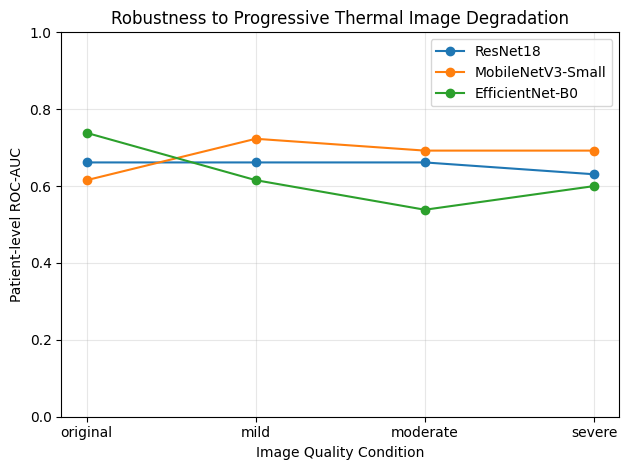

In [86]:
import matplotlib.pyplot as plt

plot_df = test_results_df.copy()

order = [
    "original",
    "mild",
    "moderate",
    "severe"
]

for model_name in plot_df["model"].unique():

    temp = (
        plot_df[
            plot_df["model"] == model_name
        ]
        .set_index("degradation")
        .loc[order]
    )

    plt.plot(
        order,
        temp["auc"],
        marker="o",
        label=model_name
    )

plt.xlabel("Image Quality Condition")
plt.ylabel("Patient-level ROC-AUC")
plt.ylim(0, 1)
plt.title(
    "Robustness to Progressive Thermal Image Degradation"
)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    FIGURES_DIR /
    "patient_auc_vs_degradation.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [87]:
def predict_with_metadata(
    model,
    dataframe,
    degradation="original",
    degradation_seed=42
):

    dataset = BreastThermographyDataset(
        dataframe,
        transform=eval_transform,
        degradation=degradation,
        seed=degradation_seed
    )

    loader = DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=2
    )

    model.eval()

    probabilities = []

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(DEVICE)

            outputs = model(images)

            probs = torch.softmax(
                outputs,
                dim=1
            )[:, 1]

            probabilities.extend(
                probs.cpu().numpy()
            )

    results = (
        dataframe
        .copy()
        .reset_index(drop=True)
    )

    results["prob_malignant"] = probabilities

    return results

In [88]:
def evaluate_patient_level_seed(
    model,
    dataframe,
    degradation,
    threshold,
    degradation_seed
):

    predictions = predict_with_metadata(
        model,
        dataframe,
        degradation=degradation,
        degradation_seed=degradation_seed
    )

    patient_df = (
        predictions
        .groupby(
            ["patient_id", "label"],
            as_index=False
        )["prob_malignant"]
        .mean()
    )

    patient_df["prediction"] = (
        patient_df["prob_malignant"] >= threshold
    ).astype(int)

    y_true = patient_df["label"]
    y_pred = patient_df["prediction"]
    y_prob = patient_df["prob_malignant"]

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1]
    ).ravel()

    return {
        "accuracy": accuracy_score(y_true, y_pred),

        "sensitivity":
            tp / (tp + fn)
            if (tp + fn) > 0 else np.nan,

        "specificity":
            tn / (tn + fp)
            if (tn + fp) > 0 else np.nan,

        "precision": precision_score(
            y_true,
            y_pred,
            zero_division=0
        ),

        "f1": f1_score(
            y_true,
            y_pred,
            zero_division=0
        ),

        "auc": roc_auc_score(
            y_true,
            y_prob
        )
    }

In [89]:
CORRUPTION_SEEDS = list(range(20))

models_to_test = [
    (
        "ResNet18",
        model_full,
        RESNET_THRESHOLD
    ),
    (
        "MobileNetV3-Small",
        mobile_model,
        MOBILE_THRESHOLD
    ),
    (
        "EfficientNet-B0",
        eff_model,
        EFF_THRESHOLD
    )
]

levels = [
    "original",
    "mild",
    "moderate",
    "severe"
]

robustness_results = []

for model_name, mdl, threshold in models_to_test:

    print("\n", model_name)

    for level in levels:

        # Original has no random corruption,
        # therefore one evaluation is sufficient
        seeds = (
            [42]
            if level == "original"
            else CORRUPTION_SEEDS
        )

        for seed in seeds:

            result = evaluate_patient_level_seed(
                mdl,
                test_df,
                degradation=level,
                threshold=threshold,
                degradation_seed=seed
            )

            robustness_results.append({
                "model": model_name,
                "degradation": level,
                "seed": seed,
                **result
            })

        print(
            level,
            "completed:",
            len(seeds),
            "runs"
        )

robustness_df = pd.DataFrame(
    robustness_results
)

robustness_df.to_csv(
    RESULTS_DIR /
    "multi_seed_degradation_results.csv",
    index=False
)

print("\nCompleted.")


 ResNet18
original completed: 1 runs
mild completed: 20 runs
moderate completed: 20 runs
severe completed: 20 runs

 MobileNetV3-Small
original completed: 1 runs
mild completed: 20 runs
moderate completed: 20 runs
severe completed: 20 runs

 EfficientNet-B0
original completed: 1 runs
mild completed: 20 runs
moderate completed: 20 runs
severe completed: 20 runs

Completed.


In [90]:
summary_df = (
    robustness_df
    .groupby(
        ["model", "degradation"]
    )
    .agg(
        auc_mean=("auc", "mean"),
        auc_std=("auc", "std"),

        accuracy_mean=("accuracy", "mean"),
        accuracy_std=("accuracy", "std"),

        sensitivity_mean=("sensitivity", "mean"),
        sensitivity_std=("sensitivity", "std"),

        specificity_mean=("specificity", "mean"),
        specificity_std=("specificity", "std"),

        f1_mean=("f1", "mean"),
        f1_std=("f1", "std")
    )
    .reset_index()
)

display(summary_df)

summary_df.to_csv(
    RESULTS_DIR /
    "multi_seed_degradation_summary.csv",
    index=False
)

,model,degradation,auc_mean,auc_std,accuracy_mean,accuracy_std,sensitivity_mean,sensitivity_std,specificity_mean,specificity_std,f1_mean,f1_std
0,EfficientNet-B0,mild,0.719231,0.056223,0.375000,0.043689,0.83,0.073270,0.200000,0.046019,0.424599,0.035279
1,EfficientNet-B0,moderate,0.595385,0.048676,0.363889,0.033600,0.80,0.000000,0.196154,0.046523,0.411696,0.013035
2,EfficientNet-B0,original,0.738462,NaN,0.444444,NaN,1.00,NaN,0.230769,NaN,0.500000,NaN
3,EfficientNet-B0,severe,0.520000,0.118918,0.277778,0.000000,1.00,0.000000,0.000000,0.000000,0.434783,0.000000
4,MobileNetV3-Small,mild,0.727692,0.025500,0.708333,0.039797,0.63,0.073270,0.738462,0.046019,0.545618,0.053202
5,MobileNetV3-Small,moderate,0.727692,0.034256,0.827778,0.053773,0.51,0.120961,0.950000,0.051602,0.618254,0.126936
6,MobileNetV3-Small,original,0.615385,NaN,0.500000,NaN,0.40,NaN,0.538462,NaN,0.307692,NaN
7,MobileNetV3-Small,severe,0.721538,0.037981,0.727778,0.017100,0.02,0.061559,1.000000,0.000000,0.033333,0.102598
8,ResNet18,mild,0.696923,0.029148,0.638889,0.038236,0.54,0.094032,0.676923,0.040242,0.452156,0.066076
9,ResNet18,moderate,0.708462,0.026635,0.561111,0.043782,0.47,0.097872,0.596154,0.049128,0.371570,0.064321


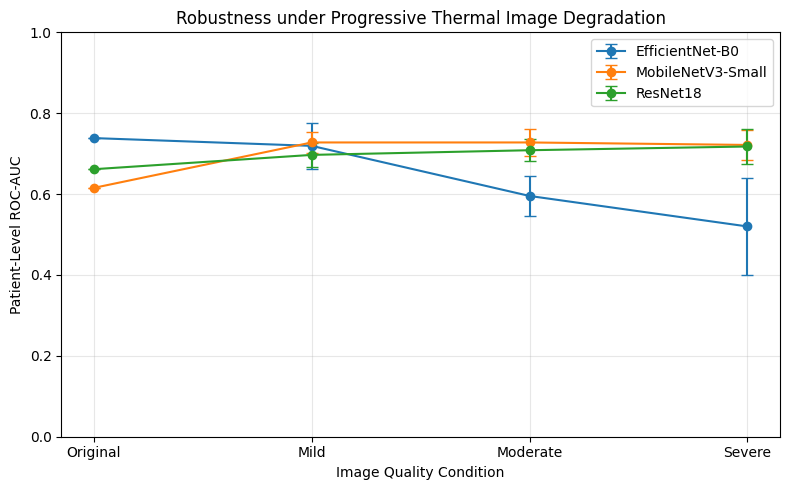

In [91]:
order = [
    "original",
    "mild",
    "moderate",
    "severe"
]

plt.figure(figsize=(8, 5))

for model_name in summary_df["model"].unique():

    temp = (
        summary_df[
            summary_df["model"] == model_name
        ]
        .set_index("degradation")
        .loc[order]
    )

    x = np.arange(len(order))

    means = temp["auc_mean"].values

    errors = (
        temp["auc_std"]
        .fillna(0)
        .values
    )

    plt.errorbar(
        x,
        means,
        yerr=errors,
        marker="o",
        capsize=4,
        label=model_name
    )

plt.xticks(
    np.arange(len(order)),
    ["Original", "Mild", "Moderate", "Severe"]
)

plt.xlabel("Image Quality Condition")
plt.ylabel("Patient-Level ROC-AUC")

plt.ylim(0, 1)

plt.title(
    "Robustness under Progressive Thermal Image Degradation"
)

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR /
    "multiseed_auc_degradation.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [92]:
probability_results = []

for model_name, mdl, threshold in models_to_test:

    for level in levels:

        seeds = [42] if level == "original" else CORRUPTION_SEEDS

        for seed in seeds:

            preds = predict_with_metadata(
                mdl,
                test_df,
                degradation=level,
                degradation_seed=seed
            )

            patient_preds = (
                preds
                .groupby(
                    ["patient_id", "label"],
                    as_index=False
                )["prob_malignant"]
                .mean()
            )

            for _, row in patient_preds.iterrows():

                probability_results.append({
                    "model": model_name,
                    "degradation": level,
                    "seed": seed,
                    "patient_id": row["patient_id"],
                    "label": row["label"],
                    "prob_malignant": row["prob_malignant"]
                })

probability_df = pd.DataFrame(probability_results)

probability_df.to_csv(
    RESULTS_DIR / "patient_probability_degradation.csv",
    index=False
)

print("Saved:", len(probability_df), "patient predictions")

Saved: 3294 patient predictions


In [93]:
prob_summary = (
    probability_df
    .groupby(
        ["model", "degradation", "label"]
    )
    .agg(
        mean_probability=("prob_malignant", "mean"),
        std_probability=("prob_malignant", "std")
    )
    .reset_index()
)

prob_summary["class"] = prob_summary["label"].map({
    0: "Benign",
    1: "Malignant"
})

display(
    prob_summary[
        [
            "model",
            "degradation",
            "class",
            "mean_probability",
            "std_probability"
        ]
    ]
)

,model,degradation,class,mean_probability,std_probability
0,EfficientNet-B0,mild,Benign,0.411522,0.040002
1,EfficientNet-B0,mild,Malignant,0.445187,0.045994
2,EfficientNet-B0,moderate,Benign,0.431853,0.055934
3,EfficientNet-B0,moderate,Malignant,0.449076,0.052112
4,EfficientNet-B0,original,Benign,0.428864,0.063771
5,EfficientNet-B0,original,Malignant,0.468583,0.033626
6,EfficientNet-B0,severe,Benign,0.561099,0.019600
7,EfficientNet-B0,severe,Malignant,0.560630,0.017505
8,MobileNetV3-Small,mild,Benign,0.306919,0.100034
9,MobileNetV3-Small,mild,Malignant,0.399345,0.127454


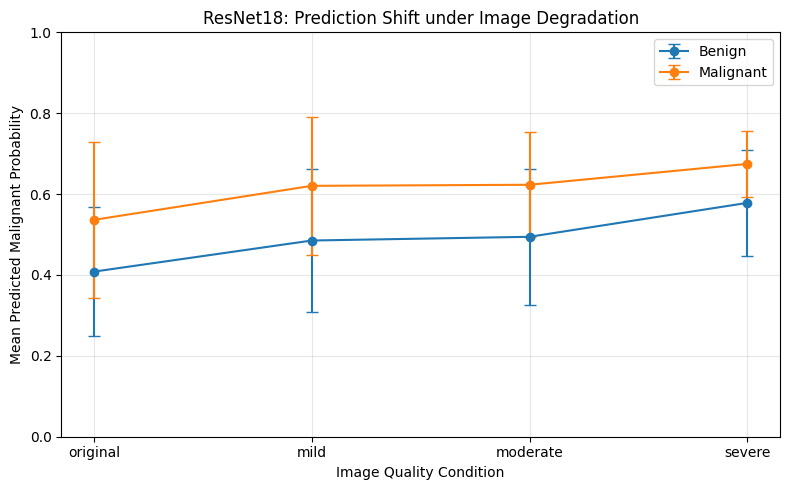

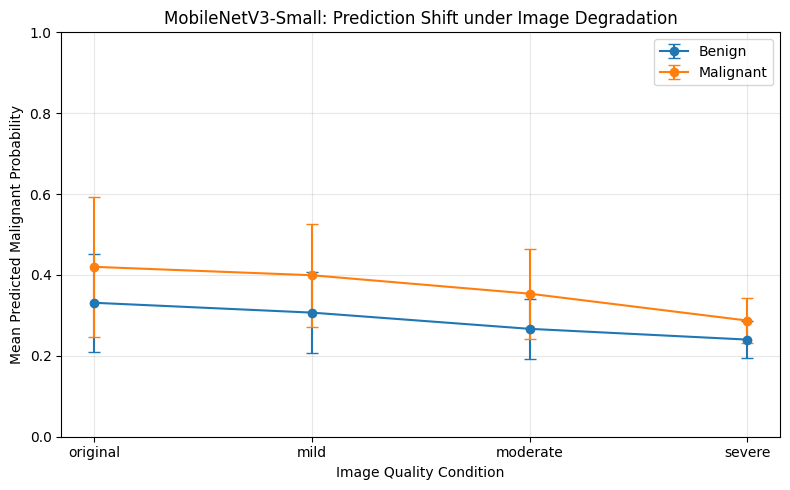

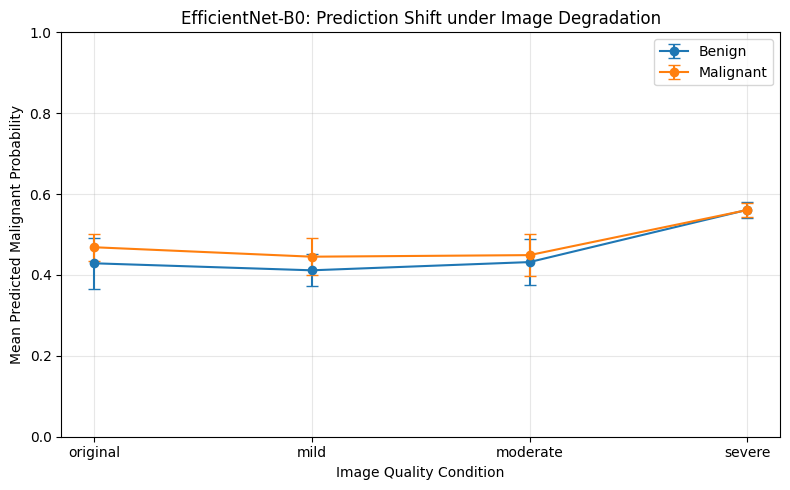

In [94]:
import matplotlib.pyplot as plt

order = ["original", "mild", "moderate", "severe"]

for model_name in probability_df["model"].unique():

    temp = probability_df[
        probability_df["model"] == model_name
    ]

    plt.figure(figsize=(8, 5))

    for label, class_name in [
        (0, "Benign"),
        (1, "Malignant")
    ]:

        means = []
        errors = []

        for level in order:

            vals = temp[
                (temp["degradation"] == level) &
                (temp["label"] == label)
            ]["prob_malignant"]

            means.append(vals.mean())
            errors.append(vals.std())

        plt.errorbar(
            order,
            means,
            yerr=errors,
            marker="o",
            capsize=4,
            label=class_name
        )

    plt.xlabel("Image Quality Condition")
    plt.ylabel("Mean Predicted Malignant Probability")
    plt.ylim(0, 1)

    plt.title(
        f"{model_name}: Prediction Shift under Image Degradation"
    )

    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()

    filename = (
        FIGURES_DIR /
        f"{model_name.lower().replace('-', '_')}_probability_shift.png"
    )

    plt.savefig(
        filename,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

In [95]:
import random
import numpy as np
from torch.utils.data import Dataset, DataLoader
from PIL import Image

QUALITY_LEVELS = [
    "original",
    "mild",
    "moderate",
    "severe"
]

QUALITY_PROBS = [
    0.40,
    0.20,
    0.20,
    0.20
]

class QualityAwareBreastDataset(Dataset):

    def __init__(
        self,
        dataframe,
        transform=None
    ):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        image = Image.open(
            row["filepath"]
        ).convert("RGB")

        # Random quality condition
        level = np.random.choice(
            QUALITY_LEVELS,
            p=QUALITY_PROBS
        )

        if level != "original":
            image = degrade_image(
                image,
                level
            )

        if self.transform:
            image = self.transform(image)

        label = int(row["label"])

        return image, label

In [96]:
def seed_worker(worker_id):

    worker_seed = (
        torch.initial_seed() % 2**32
    )

    np.random.seed(worker_seed)
    random.seed(worker_seed)


generator = torch.Generator()
generator.manual_seed(42)


quality_train_dataset = QualityAwareBreastDataset(
    train_df,
    transform=train_transform
)

quality_train_loader = DataLoader(
    quality_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    worker_init_fn=seed_worker,
    generator=generator
)

print(
    "Quality-aware training images:",
    len(quality_train_dataset)
)

print(
    "Batches:",
    len(quality_train_loader)
)

print(
    "Quality probabilities:",
    dict(zip(
        QUALITY_LEVELS,
        QUALITY_PROBS
    ))
)

Quality-aware training images: 249
Batches: 16
Quality probabilities: {'original': 0.4, 'mild': 0.2, 'moderate': 0.2, 'severe': 0.2}


In [97]:
from torchvision.models import (
    resnet18,
    ResNet18_Weights
)

qa_resnet = resnet18(
    weights=ResNet18_Weights.DEFAULT
)

num_features = qa_resnet.fc.in_features

qa_resnet.fc = nn.Sequential(
    nn.Dropout(p=0.30),
    nn.Linear(
        num_features,
        2
    )
)

qa_resnet = qa_resnet.to(DEVICE)

qa_resnet_optimizer = torch.optim.AdamW(
    qa_resnet.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

qa_resnet_scheduler = (
    torch.optim.lr_scheduler.ReduceLROnPlateau(
        qa_resnet_optimizer,
        mode="min",
        factor=0.5,
        patience=2
    )
)

criterion = nn.CrossEntropyLoss(
    weight=class_weights
)

print(
    "QA ResNet parameters:",
    sum(
        p.numel()
        for p in qa_resnet.parameters()
    )
)

QA ResNet parameters: 11177538


In [98]:
EPOCHS = 20
EARLY_STOP_PATIENCE = 5

best_val_loss = float("inf")
best_epoch = 0
patience_counter = 0

qa_resnet_history = []

QA_RESNET_PATH = (
    MODELS_DIR /
    "resnet18_quality_augmented_best.pt"
)

for epoch in range(1, EPOCHS + 1):

    train_metrics = run_epoch(
        qa_resnet,
        quality_train_loader,
        criterion,
        qa_resnet_optimizer
    )

    # Validation remains CLEAN
    val_metrics = run_epoch(
        qa_resnet,
        val_loader,
        criterion
    )

    qa_resnet_scheduler.step(
        val_metrics["loss"]
    )

    p_auc = patient_level_auc(
        qa_resnet,
        val_df
    )

    qa_resnet_history.append({
        "epoch": epoch,

        "train_loss":
            train_metrics["loss"],

        "train_auc":
            train_metrics["auc"],

        "val_loss":
            val_metrics["loss"],

        "val_acc":
            val_metrics["accuracy"],

        "val_f1":
            val_metrics["f1"],

        "image_val_auc":
            val_metrics["auc"],

        "patient_val_auc":
            p_auc
    })

    print(
        f"Epoch {epoch:02d} | "
        f"Train Loss {train_metrics['loss']:.4f} | "
        f"Train AUC {train_metrics['auc']:.3f} || "
        f"Val Loss {val_metrics['loss']:.4f} | "
        f"Val Acc {val_metrics['accuracy']:.3f} | "
        f"Val F1 {val_metrics['f1']:.3f} | "
        f"Image AUC {val_metrics['auc']:.3f} | "
        f"Patient AUC {p_auc:.3f}"
    )

    # SAME selection rule as before:
    # minimum clean validation loss
    if val_metrics["loss"] < best_val_loss:

        best_val_loss = val_metrics["loss"]
        best_epoch = epoch
        patience_counter = 0

        torch.save(
            qa_resnet.state_dict(),
            QA_RESNET_PATH
        )

        print(
            "   -> Best QA ResNet saved"
        )

    else:
        patience_counter += 1

    if patience_counter >= EARLY_STOP_PATIENCE:

        print(
            f"\nEarly stopping at epoch {epoch}"
        )
        break


qa_resnet_history_df = pd.DataFrame(
    qa_resnet_history
)

qa_resnet_history_df.to_csv(
    RESULTS_DIR /
    "resnet18_quality_augmented_history.csv",
    index=False
)

print("\nBest epoch:", best_epoch)
print(
    "Best validation loss:",
    best_val_loss
)
print("Saved:", QA_RESNET_PATH)

Epoch 01 | Train Loss 0.7787 | Train AUC 0.581 || Val Loss 0.9526 | Val Acc 0.667 | Val F1 0.000 | Image AUC 0.452 | Patient AUC 0.417
   -> Best QA ResNet saved
Epoch 02 | Train Loss 0.5714 | Train AUC 0.765 || Val Loss 0.8779 | Val Acc 0.630 | Val F1 0.231 | Image AUC 0.461 | Patient AUC 0.431
   -> Best QA ResNet saved
Epoch 03 | Train Loss 0.4964 | Train AUC 0.837 || Val Loss 1.0479 | Val Acc 0.648 | Val F1 0.240 | Image AUC 0.463 | Patient AUC 0.431
Epoch 04 | Train Loss 0.4218 | Train AUC 0.890 || Val Loss 1.0242 | Val Acc 0.519 | Val F1 0.133 | Image AUC 0.424 | Patient AUC 0.431
Epoch 05 | Train Loss 0.4139 | Train AUC 0.886 || Val Loss 1.0022 | Val Acc 0.704 | Val F1 0.200 | Image AUC 0.471 | Patient AUC 0.458
Epoch 06 | Train Loss 0.3603 | Train AUC 0.917 || Val Loss 0.9921 | Val Acc 0.426 | Val F1 0.279 | Image AUC 0.444 | Patient AUC 0.431
Epoch 07 | Train Loss 0.3165 | Train AUC 0.941 || Val Loss 1.0547 | Val Acc 0.463 | Val F1 0.293 | Image AUC 0.485 | Patient AUC 0.458



In [99]:
from torchvision.models import (
    mobilenet_v3_small,
    MobileNet_V3_Small_Weights
)

qa_mobile = mobilenet_v3_small(
    weights=MobileNet_V3_Small_Weights.DEFAULT
)

in_features = (
    qa_mobile.classifier[3].in_features
)

qa_mobile.classifier[3] = nn.Sequential(
    nn.Dropout(p=0.30),
    nn.Linear(
        in_features,
        2
    )
)

qa_mobile = qa_mobile.to(DEVICE)

qa_mobile_optimizer = torch.optim.AdamW(
    qa_mobile.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

qa_mobile_scheduler = (
    torch.optim.lr_scheduler.ReduceLROnPlateau(
        qa_mobile_optimizer,
        mode="min",
        factor=0.5,
        patience=2
    )
)

print(
    "QA MobileNet parameters:",
    sum(
        p.numel()
        for p in qa_mobile.parameters()
    )
)

QA MobileNet parameters: 1519906


In [100]:
best_val_loss = float("inf")
best_epoch = 0
patience_counter = 0

qa_mobile_history = []

QA_MOBILE_PATH = (
    MODELS_DIR /
    "mobilenetv3_quality_augmented_best.pt"
)

for epoch in range(1, EPOCHS + 1):

    train_metrics = run_epoch(
        qa_mobile,
        quality_train_loader,
        criterion,
        qa_mobile_optimizer
    )

    val_metrics = run_epoch(
        qa_mobile,
        val_loader,
        criterion
    )

    qa_mobile_scheduler.step(
        val_metrics["loss"]
    )

    p_auc = patient_level_auc(
        qa_mobile,
        val_df
    )

    qa_mobile_history.append({
        "epoch": epoch,
        "train_loss":
            train_metrics["loss"],
        "train_auc":
            train_metrics["auc"],
        "val_loss":
            val_metrics["loss"],
        "val_acc":
            val_metrics["accuracy"],
        "val_f1":
            val_metrics["f1"],
        "image_val_auc":
            val_metrics["auc"],
        "patient_val_auc":
            p_auc
    })

    print(
        f"Epoch {epoch:02d} | "
        f"Train Loss {train_metrics['loss']:.4f} | "
        f"Train AUC {train_metrics['auc']:.3f} || "
        f"Val Loss {val_metrics['loss']:.4f} | "
        f"Val Acc {val_metrics['accuracy']:.3f} | "
        f"Val F1 {val_metrics['f1']:.3f} | "
        f"Image AUC {val_metrics['auc']:.3f} | "
        f"Patient AUC {p_auc:.3f}"
    )

    if val_metrics["loss"] < best_val_loss:

        best_val_loss = val_metrics["loss"]
        best_epoch = epoch
        patience_counter = 0

        torch.save(
            qa_mobile.state_dict(),
            QA_MOBILE_PATH
        )

        print(
            "   -> Best QA MobileNet saved"
        )

    else:
        patience_counter += 1

    if patience_counter >= EARLY_STOP_PATIENCE:

        print(
            f"\nEarly stopping at epoch {epoch}"
        )
        break


qa_mobile_history_df = pd.DataFrame(
    qa_mobile_history
)

qa_mobile_history_df.to_csv(
    RESULTS_DIR /
    "mobilenetv3_quality_augmented_history.csv",
    index=False
)

print("\nBest epoch:", best_epoch)
print(
    "Best validation loss:",
    best_val_loss
)
print("Saved:", QA_MOBILE_PATH)

Epoch 01 | Train Loss 0.7136 | Train AUC 0.506 || Val Loss 0.7134 | Val Acc 0.463 | Val F1 0.171 | Image AUC 0.407 | Patient AUC 0.431
   -> Best QA MobileNet saved
Epoch 02 | Train Loss 0.6647 | Train AUC 0.628 || Val Loss 0.7303 | Val Acc 0.444 | Val F1 0.250 | Image AUC 0.392 | Patient AUC 0.417
Epoch 03 | Train Loss 0.6350 | Train AUC 0.711 || Val Loss 0.7178 | Val Acc 0.500 | Val F1 0.069 | Image AUC 0.355 | Patient AUC 0.403
Epoch 04 | Train Loss 0.6309 | Train AUC 0.699 || Val Loss 0.7162 | Val Acc 0.574 | Val F1 0.148 | Image AUC 0.400 | Patient AUC 0.444
Epoch 05 | Train Loss 0.5898 | Train AUC 0.773 || Val Loss 0.7133 | Val Acc 0.537 | Val F1 0.138 | Image AUC 0.441 | Patient AUC 0.431
   -> Best QA MobileNet saved
Epoch 06 | Train Loss 0.5904 | Train AUC 0.751 || Val Loss 0.7302 | Val Acc 0.593 | Val F1 0.154 | Image AUC 0.440 | Patient AUC 0.417
Epoch 07 | Train Loss 0.5745 | Train AUC 0.779 || Val Loss 0.7354 | Val Acc 0.574 | Val F1 0.207 | Image AUC 0.465 | Patient AUC 0

In [10]:
from pathlib import Path
import torch
import numpy as np
import pandas as pd
import random

# ============================================================
# RESTORE PROJECT PATHS
# ============================================================

PROJECT = Path(
    "/content/drive/MyDrive/ICVGIP_Breast_Thermography"
)

DATA_DIR = PROJECT / "data"
RESULTS_DIR = PROJECT / "results"
MODELS_DIR = PROJECT / "models"
FIGURES_DIR = PROJECT / "figures"

# Create folders if necessary
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# ============================================================
# DEVICE
# ============================================================

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

IMG_SIZE = 224
BATCH_SIZE = 16
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ============================================================
# CHECK IMPORTANT FILES
# ============================================================

SPLIT_CSV = (
    RESULTS_DIR /
    "dataset_with_patient_split.csv"
)

QA_RESNET_PATH = (
    MODELS_DIR /
    "resnet18_quality_augmented_best.pt"
)

QA_MOBILE_PATH = (
    MODELS_DIR /
    "mobilenetv3_quality_augmented_best.pt"
)

print("PROJECT:", PROJECT)
print("DEVICE:", DEVICE)

print("\nChecking saved files...")
print("Dataset split:", SPLIT_CSV.exists())
print("QA ResNet:", QA_RESNET_PATH.exists())
print("QA MobileNet:", QA_MOBILE_PATH.exists())

PROJECT: /content/drive/MyDrive/ICVGIP_Breast_Thermography
DEVICE: cuda

Checking saved files...
Dataset split: True
QA ResNet: True
QA MobileNet: True


In [11]:
from pathlib import Path
import torch
import numpy as np
import pandas as pd
import random

# ============================================================
# RESTORE PROJECT PATHS
# ============================================================

PROJECT = Path(
    "/content/drive/MyDrive/ICVGIP_Breast_Thermography"
)

DATA_DIR = PROJECT / "data"
RESULTS_DIR = PROJECT / "results"
MODELS_DIR = PROJECT / "models"
FIGURES_DIR = PROJECT / "figures"

# Create folders if necessary
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# ============================================================
# DEVICE
# ============================================================

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

IMG_SIZE = 224
BATCH_SIZE = 16
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ============================================================
# CHECK IMPORTANT FILES
# ============================================================

SPLIT_CSV = (
    RESULTS_DIR /
    "dataset_with_patient_split.csv"
)

QA_RESNET_PATH = (
    MODELS_DIR /
    "resnet18_quality_augmented_best.pt"
)

QA_MOBILE_PATH = (
    MODELS_DIR /
    "mobilenetv3_quality_augmented_best.pt"
)

print("PROJECT:", PROJECT)
print("DEVICE:", DEVICE)

print("\nChecking saved files...")
print("Dataset split:", SPLIT_CSV.exists())
print("QA ResNet:", QA_RESNET_PATH.exists())
print("QA MobileNet:", QA_MOBILE_PATH.exists())

PROJECT: /content/drive/MyDrive/ICVGIP_Breast_Thermography
DEVICE: cuda

Checking saved files...
Dataset split: True
QA ResNet: True
QA MobileNet: True


In [12]:
import torch
import torch.nn as nn

from torchvision.models import (
    resnet18,
    ResNet18_Weights,
    mobilenet_v3_small,
    MobileNet_V3_Small_Weights
)

# -------------------------------------------------
# Paths
# -------------------------------------------------

QA_RESNET_PATH = (
    MODELS_DIR /
    "resnet18_quality_augmented_best.pt"
)

QA_MOBILE_PATH = (
    MODELS_DIR /
    "mobilenetv3_quality_augmented_best.pt"
)

print("ResNet checkpoint exists:", QA_RESNET_PATH.exists())
print("MobileNet checkpoint exists:", QA_MOBILE_PATH.exists())


# =================================================
# RECONSTRUCT QUALITY-AWARE RESNET-18
# =================================================

qa_resnet = resnet18(weights=None)

num_features = qa_resnet.fc.in_features

qa_resnet.fc = nn.Sequential(
    nn.Dropout(p=0.30),
    nn.Linear(num_features, 2)
)

qa_resnet = qa_resnet.to(DEVICE)

qa_resnet.load_state_dict(
    torch.load(
        QA_RESNET_PATH,
        map_location=DEVICE
    )
)

qa_resnet.eval()

print("\nQA ResNet-18 loaded successfully.")


# =================================================
# RECONSTRUCT QUALITY-AWARE MOBILENETV3-SMALL
# =================================================

qa_mobile = mobilenet_v3_small(
    weights=None
)

in_features = (
    qa_mobile.classifier[3].in_features
)

qa_mobile.classifier[3] = nn.Sequential(
    nn.Dropout(p=0.30),
    nn.Linear(in_features, 2)
)

qa_mobile = qa_mobile.to(DEVICE)

qa_mobile.load_state_dict(
    torch.load(
        QA_MOBILE_PATH,
        map_location=DEVICE
    )
)

qa_mobile.eval()

print("QA MobileNetV3-Small loaded successfully.")

ResNet checkpoint exists: True
MobileNet checkpoint exists: True

QA ResNet-18 loaded successfully.
QA MobileNetV3-Small loaded successfully.


In [15]:
import pandas as pd
from pathlib import Path

PROJECT = Path("/content/drive/MyDrive/ICVGIP_Breast_Thermography")
RESULTS_DIR = PROJECT / "results"
MODELS_DIR = PROJECT / "models"
FIGURES_DIR = PROJECT / "figures"

SPLIT_CSV = RESULTS_DIR / "dataset_with_patient_split.csv"

df = pd.read_csv(SPLIT_CSV)

train_df = df[df["split"] == "train"].reset_index(drop=True)
val_df   = df[df["split"] == "val"].reset_index(drop=True)
test_df  = df[df["split"] == "test"].reset_index(drop=True)

print("Train:", len(train_df), "images /", train_df["patient_id"].nunique(), "patients")
print("Val:", len(val_df), "images /", val_df["patient_id"].nunique(), "patients")
print("Test:", len(test_df), "images /", test_df["patient_id"].nunique(), "patients")

Train: 249 images / 83 patients
Val: 54 images / 18 patients
Test: 54 images / 18 patients


In [16]:
import cv2
import numpy as np
import torch

from PIL import Image, ImageEnhance
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve
)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IMG_SIZE = 224
BATCH_SIZE = 16

normalize = transforms.Normalize(
    mean=[0.485, 0.456, 0.406],
    std=[0.229, 0.224, 0.225]
)

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    normalize
])


def degrade_image(image, level="original"):

    image = image.convert("RGB")
    img = np.array(image)

    h, w = img.shape[:2]

    if level == "original":
        return Image.fromarray(img)

    elif level == "mild":
        scale = 0.75
        blur_sigma = 0.5
        noise_std = 5
        contrast = 0.90

    elif level == "moderate":
        scale = 0.50
        blur_sigma = 1.0
        noise_std = 10
        contrast = 0.75

    elif level == "severe":
        scale = 0.25
        blur_sigma = 2.0
        noise_std = 20
        contrast = 0.60

    else:
        raise ValueError("Invalid degradation level")

    new_w = max(1, int(w * scale))
    new_h = max(1, int(h * scale))

    img = cv2.resize(
        img,
        (new_w, new_h),
        interpolation=cv2.INTER_AREA
    )

    img = cv2.resize(
        img,
        (w, h),
        interpolation=cv2.INTER_LINEAR
    )

    img = cv2.GaussianBlur(
        img,
        (0, 0),
        sigmaX=blur_sigma
    )

    noise = np.random.normal(
        0,
        noise_std,
        img.shape
    ).astype(np.float32)

    img = img.astype(np.float32) + noise
    img = np.clip(img, 0, 255).astype(np.uint8)

    pil_img = Image.fromarray(img)

    pil_img = ImageEnhance.Contrast(
        pil_img
    ).enhance(contrast)

    return pil_img

In [17]:
class BreastThermographyDataset(Dataset):

    def __init__(
        self,
        dataframe,
        transform=None,
        degradation="original",
        seed=42
    ):

        self.df = dataframe.reset_index(drop=True)
        self.transform = transform
        self.degradation = degradation
        self.seed = seed

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        image = Image.open(
            row["filepath"]
        ).convert("RGB")

        if self.degradation != "original":

            state = np.random.get_state()

            np.random.seed(
                self.seed + idx
            )

            image = degrade_image(
                image,
                self.degradation
            )

            np.random.set_state(state)

        if self.transform:
            image = self.transform(image)

        return image, int(row["label"])

In [18]:
def predict_with_metadata(
    model,
    dataframe,
    degradation="original",
    degradation_seed=42
):

    dataset = BreastThermographyDataset(
        dataframe,
        transform=eval_transform,
        degradation=degradation,
        seed=degradation_seed
    )

    loader = DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=2
    )

    model.eval()

    probabilities = []

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(DEVICE)

            outputs = model(images)

            probs = torch.softmax(
                outputs,
                dim=1
            )[:, 1]

            probabilities.extend(
                probs.cpu().numpy()
            )

    results = dataframe.copy().reset_index(drop=True)

    results["prob_malignant"] = probabilities

    return results


def find_youden_threshold(patient_df):

    y_true = patient_df["label"].values
    y_prob = patient_df["prob_malignant"].values

    fpr, tpr, thresholds = roc_curve(
        y_true,
        y_prob
    )

    j = tpr - fpr

    idx = np.argmax(j)

    return {
        "threshold": thresholds[idx],
        "sensitivity": tpr[idx],
        "specificity": 1 - fpr[idx]
    }

In [19]:
qa_resnet_val_predictions = predict_with_metadata(
    qa_resnet,
    val_df,
    degradation="original",
    degradation_seed=42
)

qa_resnet_patient_val = (
    qa_resnet_val_predictions
    .groupby(
        ["patient_id", "label"],
        as_index=False
    )["prob_malignant"]
    .mean()
)


qa_mobile_val_predictions = predict_with_metadata(
    qa_mobile,
    val_df,
    degradation="original",
    degradation_seed=42
)

qa_mobile_patient_val = (
    qa_mobile_val_predictions
    .groupby(
        ["patient_id", "label"],
        as_index=False
    )["prob_malignant"]
    .mean()
)


qa_resnet_threshold_info = find_youden_threshold(
    qa_resnet_patient_val
)

qa_mobile_threshold_info = find_youden_threshold(
    qa_mobile_patient_val
)

print("QA ResNet:")
print(qa_resnet_threshold_info)

print("\nQA MobileNet:")
print(qa_mobile_threshold_info)

QA ResNet:
{'threshold': np.float32(0.7037425), 'sensitivity': np.float64(0.16666666666666666), 'specificity': np.float64(1.0)}

QA MobileNet:
{'threshold': np.float32(0.32764348), 'sensitivity': np.float64(1.0), 'specificity': np.float64(0.25)}


In [20]:
QA_RESNET_THRESHOLD = float(
    qa_resnet_threshold_info["threshold"]
)

QA_MOBILE_THRESHOLD = float(
    qa_mobile_threshold_info["threshold"]
)

print("\nFrozen thresholds")
print("QA ResNet:", QA_RESNET_THRESHOLD)
print("QA MobileNet:", QA_MOBILE_THRESHOLD)


Frozen thresholds
QA ResNet: 0.703742504119873
QA MobileNet: 0.327643483877182


In [21]:
def evaluate_patient_level_seed(
    model,
    dataframe,
    degradation,
    threshold,
    degradation_seed
):

    predictions = predict_with_metadata(
        model,
        dataframe,
        degradation=degradation,
        degradation_seed=degradation_seed
    )

    patient_df = (
        predictions
        .groupby(
            ["patient_id", "label"],
            as_index=False
        )["prob_malignant"]
        .mean()
    )

    patient_df["prediction"] = (
        patient_df["prob_malignant"] >= threshold
    ).astype(int)

    y_true = patient_df["label"]
    y_pred = patient_df["prediction"]
    y_prob = patient_df["prob_malignant"]

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1]
    ).ravel()

    sensitivity = (
        tp / (tp + fn)
        if (tp + fn) > 0 else np.nan
    )

    specificity = (
        tn / (tn + fp)
        if (tn + fp) > 0 else np.nan
    )

    return {
        "accuracy": accuracy_score(
            y_true,
            y_pred
        ),

        "sensitivity": sensitivity,

        "specificity": specificity,

        "precision": precision_score(
            y_true,
            y_pred,
            zero_division=0
        ),

        "f1": f1_score(
            y_true,
            y_pred,
            zero_division=0
        ),

        "auc": roc_auc_score(
            y_true,
            y_prob
        )
    }

In [22]:
CORRUPTION_SEEDS = list(range(20))

levels = [
    "original",
    "mild",
    "moderate",
    "severe"
]

qa_models_to_test = [
    (
        "QA-ResNet18",
        qa_resnet,
        QA_RESNET_THRESHOLD
    ),
    (
        "QA-MobileNetV3-Small",
        qa_mobile,
        QA_MOBILE_THRESHOLD
    )
]

qa_robustness_results = []

for model_name, mdl, threshold in qa_models_to_test:

    print("\n" + "=" * 55)
    print(model_name)
    print("=" * 55)

    for level in levels:

        seeds = (
            [42]
            if level == "original"
            else CORRUPTION_SEEDS
        )

        for seed in seeds:

            result = evaluate_patient_level_seed(
                mdl,
                test_df,
                degradation=level,
                threshold=threshold,
                degradation_seed=seed
            )

            qa_robustness_results.append({
                "model": model_name,
                "degradation": level,
                "seed": seed,
                **result
            })

        print(
            level,
            "completed:",
            len(seeds),
            "runs"
        )

qa_robustness_df = pd.DataFrame(
    qa_robustness_results
)

qa_robustness_df.to_csv(
    RESULTS_DIR /
    "quality_augmented_multiseed_results.csv",
    index=False
)

print("\nExperiment completed.")


QA-ResNet18
original completed: 1 runs
mild completed: 20 runs
moderate completed: 20 runs
severe completed: 20 runs

QA-MobileNetV3-Small
original completed: 1 runs
mild completed: 20 runs
moderate completed: 20 runs
severe completed: 20 runs

Experiment completed.


In [23]:
qa_summary_df = (
    qa_robustness_df
    .groupby(
        ["model", "degradation"]
    )
    .agg(
        auc_mean=("auc", "mean"),
        auc_std=("auc", "std"),

        accuracy_mean=("accuracy", "mean"),
        accuracy_std=("accuracy", "std"),

        sensitivity_mean=("sensitivity", "mean"),
        sensitivity_std=("sensitivity", "std"),

        specificity_mean=("specificity", "mean"),
        specificity_std=("specificity", "std"),

        f1_mean=("f1", "mean"),
        f1_std=("f1", "std")
    )
    .reset_index()
)

display(qa_summary_df)

qa_summary_df.to_csv(
    RESULTS_DIR /
    "quality_augmented_multiseed_summary.csv",
    index=False
)

,model,degradation,auc_mean,auc_std,accuracy_mean,accuracy_std,sensitivity_mean,sensitivity_std,specificity_mean,specificity_std,f1_mean,f1_std
0,QA-MobileNetV3-Small,mild,0.767692,0.024907,0.613889,0.081560,0.77,0.07327,0.553846,0.107634,0.529454,0.066226
1,QA-MobileNetV3-Small,moderate,0.829231,0.015705,0.805556,0.045954,0.77,0.07327,0.819231,0.062518,0.689254,0.061913
2,QA-MobileNetV3-Small,original,0.723077,NaN,0.444444,NaN,1.00,NaN,0.230769,NaN,0.500000,NaN
3,QA-MobileNetV3-Small,severe,0.713846,0.042763,0.697222,0.045865,0.36,0.13917,0.826923,0.034174,0.389773,0.123667
4,QA-ResNet18,mild,0.711538,0.024389,0.722222,0.000000,0.00,0.00000,1.000000,0.000000,0.000000,0.000000
5,QA-ResNet18,moderate,0.692308,0.053294,0.722222,0.000000,0.00,0.00000,1.000000,0.000000,0.000000,0.000000
6,QA-ResNet18,original,0.676923,NaN,0.722222,NaN,0.00,NaN,1.000000,NaN,0.000000,NaN
7,QA-ResNet18,severe,0.572308,0.059605,0.722222,0.000000,0.00,0.00000,1.000000,0.000000,0.000000,0.000000


In [24]:
baseline_summary_path = (
    RESULTS_DIR /
    "multi_seed_degradation_summary.csv"
)

baseline_summary_df = pd.read_csv(
    baseline_summary_path
)

print(
    "Baseline summary loaded:",
    baseline_summary_path.exists()
)

Baseline summary loaded: True


In [25]:
baseline_compare = baseline_summary_df[
    baseline_summary_df["model"].isin(
        [
            "ResNet18",
            "MobileNetV3-Small"
        ]
    )
].copy()

baseline_compare["training"] = "Clean-trained"


qa_compare = qa_summary_df.copy()

qa_compare["training"] = "Quality-aware"

qa_compare["model"] = qa_compare["model"].replace({
    "QA-ResNet18": "ResNet18",
    "QA-MobileNetV3-Small":
        "MobileNetV3-Small"
})


comparison_df = pd.concat(
    [
        baseline_compare,
        qa_compare
    ],
    ignore_index=True
)

comparison_display = comparison_df[
    [
        "model",
        "training",
        "degradation",
        "auc_mean",
        "auc_std",
        "accuracy_mean",
        "sensitivity_mean",
        "specificity_mean",
        "f1_mean"
    ]
].sort_values(
    [
        "model",
        "degradation",
        "training"
    ]
)

display(comparison_display)

comparison_display.to_csv(
    RESULTS_DIR /
    "clean_vs_quality_aware_comparison.csv",
    index=False
)

,model,training,degradation,auc_mean,auc_std,accuracy_mean,sensitivity_mean,specificity_mean,f1_mean
0,MobileNetV3-Small,Clean-trained,mild,0.727692,0.025500,0.708333,0.63,0.738462,0.545618
8,MobileNetV3-Small,Quality-aware,mild,0.767692,0.024907,0.613889,0.77,0.553846,0.529454
1,MobileNetV3-Small,Clean-trained,moderate,0.727692,0.034256,0.827778,0.51,0.950000,0.618254
9,MobileNetV3-Small,Quality-aware,moderate,0.829231,0.015705,0.805556,0.77,0.819231,0.689254
2,MobileNetV3-Small,Clean-trained,original,0.615385,NaN,0.500000,0.40,0.538462,0.307692
10,MobileNetV3-Small,Quality-aware,original,0.723077,NaN,0.444444,1.00,0.230769,0.500000
3,MobileNetV3-Small,Clean-trained,severe,0.721538,0.037981,0.727778,0.02,1.000000,0.033333
11,MobileNetV3-Small,Quality-aware,severe,0.713846,0.042763,0.697222,0.36,0.826923,0.389773
4,ResNet18,Clean-trained,mild,0.696923,0.029148,0.638889,0.54,0.676923,0.452156
12,ResNet18,Quality-aware,mild,0.711538,0.024389,0.722222,0.00,1.000000,0.000000


In [26]:
from sklearn.metrics import brier_score_loss
import numpy as np
import pandas as pd


def expected_calibration_error(
    y_true,
    y_prob,
    n_bins=5
):
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)

    bins = np.linspace(0.0, 1.0, n_bins + 1)

    ece = 0.0

    for i in range(n_bins):

        if i == n_bins - 1:
            mask = (
                (y_prob >= bins[i]) &
                (y_prob <= bins[i + 1])
            )
        else:
            mask = (
                (y_prob >= bins[i]) &
                (y_prob < bins[i + 1])
            )

        if np.sum(mask) == 0:
            continue

        bin_confidence = np.mean(
            y_prob[mask]
        )

        bin_accuracy = np.mean(
            y_true[mask]
        )

        bin_weight = (
            np.sum(mask) /
            len(y_true)
        )

        ece += (
            bin_weight *
            abs(
                bin_accuracy -
                bin_confidence
            )
        )

    return ece

In [27]:
for p in MODELS_DIR.glob("*.pt"):
    print(p.name)

resnet18_original_best.pt
resnet18_frozen_best.pt
resnet18_partial_best.pt
mobilenetv3_original_best.pt
efficientnetb0_original_best.pt
resnet18_quality_augmented_best.pt
mobilenetv3_quality_augmented_best.pt


In [28]:
import torch
import torch.nn as nn

from torchvision.models import (
    resnet18,
    mobilenet_v3_small,
    efficientnet_b0
)

# ============================================================
# 1. CLEAN RESNET-18
# ============================================================

clean_resnet = resnet18(weights=None)

clean_resnet.fc = nn.Sequential(
    nn.Dropout(p=0.30),
    nn.Linear(clean_resnet.fc.in_features, 2)
)

clean_resnet.load_state_dict(
    torch.load(
        MODELS_DIR / "resnet18_original_best.pt",
        map_location=DEVICE
    )
)

clean_resnet = clean_resnet.to(DEVICE)
clean_resnet.eval()

print("Clean ResNet loaded.")


# ============================================================
# 2. CLEAN MOBILENETV3-SMALL
# ============================================================

clean_mobile = mobilenet_v3_small(weights=None)

in_features = clean_mobile.classifier[3].in_features

clean_mobile.classifier[3] = nn.Sequential(
    nn.Dropout(p=0.30),
    nn.Linear(in_features, 2)
)

clean_mobile.load_state_dict(
    torch.load(
        MODELS_DIR / "mobilenetv3_original_best.pt",
        map_location=DEVICE
    )
)

clean_mobile = clean_mobile.to(DEVICE)
clean_mobile.eval()

print("Clean MobileNet loaded.")


# ============================================================
# 3. CLEAN EFFICIENTNET-B0
# ============================================================

clean_eff = efficientnet_b0(weights=None)

in_features = clean_eff.classifier[1].in_features

clean_eff.classifier[1] = nn.Sequential(
    nn.Dropout(p=0.30),
    nn.Linear(in_features, 2)
)

clean_eff.load_state_dict(
    torch.load(
        MODELS_DIR / "efficientnetb0_original_best.pt",
        map_location=DEVICE
    )
)

clean_eff = clean_eff.to(DEVICE)
clean_eff.eval()

print("Clean EfficientNet loaded.")


# qa_resnet and qa_mobile should already be loaded
print("QA ResNet loaded:", 'qa_resnet' in globals())
print("QA MobileNet loaded:", 'qa_mobile' in globals())

Clean ResNet loaded.
Clean MobileNet loaded.
Clean EfficientNet loaded.
QA ResNet loaded: True
QA MobileNet loaded: True


In [29]:
from sklearn.metrics import (
    roc_auc_score,
    brier_score_loss
)

import numpy as np
import pandas as pd


def expected_calibration_error(
    y_true,
    y_prob,
    n_bins=5
):
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)

    bins = np.linspace(0.0, 1.0, n_bins + 1)

    ece = 0.0

    for i in range(n_bins):

        if i == n_bins - 1:
            mask = (
                (y_prob >= bins[i]) &
                (y_prob <= bins[i + 1])
            )
        else:
            mask = (
                (y_prob >= bins[i]) &
                (y_prob < bins[i + 1])
            )

        if np.sum(mask) == 0:
            continue

        confidence = np.mean(
            y_prob[mask]
        )

        accuracy = np.mean(
            y_true[mask]
        )

        weight = (
            np.sum(mask) /
            len(y_true)
        )

        ece += (
            weight *
            abs(
                accuracy -
                confidence
            )
        )

    return ece

In [30]:
def patient_probability_metrics(
    model,
    dataframe,
    degradation,
    degradation_seed
):

    preds = predict_with_metadata(
        model,
        dataframe,
        degradation=degradation,
        degradation_seed=degradation_seed
    )

    patient_df = (
        preds
        .groupby(
            ["patient_id", "label"],
            as_index=False
        )["prob_malignant"]
        .mean()
    )

    y_true = patient_df["label"].values
    y_prob = patient_df["prob_malignant"].values

    auc = roc_auc_score(
        y_true,
        y_prob
    )

    brier = brier_score_loss(
        y_true,
        y_prob
    )

    ece = expected_calibration_error(
        y_true,
        y_prob,
        n_bins=5
    )

    benign_mean = (
        patient_df.loc[
            patient_df["label"] == 0,
            "prob_malignant"
        ]
        .mean()
    )

    malignant_mean = (
        patient_df.loc[
            patient_df["label"] == 1,
            "prob_malignant"
        ]
        .mean()
    )

    return {
        "auc": auc,
        "brier": brier,
        "ece": ece,
        "benign_mean_prob": benign_mean,
        "malignant_mean_prob": malignant_mean
    }

In [31]:
FINAL_MODELS = [
    (
        "ResNet18-Clean",
        clean_resnet
    ),
    (
        "MobileNetV3-Clean",
        clean_mobile
    ),
    (
        "EfficientNetB0-Clean",
        clean_eff
    ),
    (
        "ResNet18-QA",
        qa_resnet
    ),
    (
        "MobileNetV3-QA",
        qa_mobile
    )
]

LEVELS = [
    "original",
    "mild",
    "moderate",
    "severe"
]

CORRUPTION_SEEDS = list(range(20))

calibration_results = []

for model_name, mdl in FINAL_MODELS:

    print("\n", model_name)

    for level in LEVELS:

        seeds = (
            [42]
            if level == "original"
            else CORRUPTION_SEEDS
        )

        for seed in seeds:

            m = patient_probability_metrics(
                mdl,
                test_df,
                degradation=level,
                degradation_seed=seed
            )

            calibration_results.append({
                "model": model_name,
                "degradation": level,
                "seed": seed,
                **m
            })

        print(
            level,
            "completed:",
            len(seeds),
            "runs"
        )

calibration_df = pd.DataFrame(
    calibration_results
)

calibration_df.to_csv(
    RESULTS_DIR /
    "final_calibration_results.csv",
    index=False
)

print("\nFinal calibration experiment completed.")


 ResNet18-Clean
original completed: 1 runs
mild completed: 20 runs
moderate completed: 20 runs
severe completed: 20 runs

 MobileNetV3-Clean
original completed: 1 runs
mild completed: 20 runs
moderate completed: 20 runs
severe completed: 20 runs

 EfficientNetB0-Clean
original completed: 1 runs
mild completed: 20 runs
moderate completed: 20 runs
severe completed: 20 runs

 ResNet18-QA
original completed: 1 runs
mild completed: 20 runs
moderate completed: 20 runs
severe completed: 20 runs

 MobileNetV3-QA
original completed: 1 runs
mild completed: 20 runs
moderate completed: 20 runs
severe completed: 20 runs

Final calibration experiment completed.


In [32]:
final_calibration_summary = (
    calibration_df
    .groupby(
        ["model", "degradation"]
    )
    .agg(
        auc_mean=("auc", "mean"),
        auc_std=("auc", "std"),

        brier_mean=("brier", "mean"),
        brier_std=("brier", "std"),

        ece_mean=("ece", "mean"),
        ece_std=("ece", "std"),

        benign_prob_mean=(
            "benign_mean_prob",
            "mean"
        ),

        malignant_prob_mean=(
            "malignant_mean_prob",
            "mean"
        )
    )
    .reset_index()
)

display(final_calibration_summary)

final_calibration_summary.to_csv(
    RESULTS_DIR /
    "final_calibration_summary.csv",
    index=False
)

,model,degradation,auc_mean,auc_std,brier_mean,brier_std,ece_mean,ece_std,benign_prob_mean,malignant_prob_mean
0,EfficientNetB0-Clean,mild,0.719231,0.056223,0.209546,0.003176,0.143095,0.003368,0.411522,0.445187
1,EfficientNetB0-Clean,moderate,0.595385,0.048676,0.222000,0.004245,0.158860,0.004277,0.431853,0.449076
2,EfficientNetB0-Clean,original,0.738462,NaN,0.214242,NaN,0.162119,NaN,0.428864,0.468583
3,EfficientNetB0-Clean,severe,0.520000,0.118918,0.281364,0.003382,0.283191,0.002981,0.561099,0.560630
4,MobileNetV3-Clean,mild,0.727692,0.025500,0.179917,0.003869,0.104715,0.041134,0.306919,0.399345
5,MobileNetV3-Clean,moderate,0.727692,0.034256,0.174730,0.004776,0.163652,0.059806,0.266796,0.353756
6,MobileNetV3-Clean,original,0.615385,NaN,0.189099,NaN,0.195374,NaN,0.331263,0.420129
7,MobileNetV3-Clean,severe,0.721538,0.037981,0.185166,0.002187,0.043757,0.010267,0.240185,0.287274
8,MobileNetV3-QA,mild,0.767692,0.024907,0.181078,0.001893,0.182835,0.022243,0.311885,0.383258
9,MobileNetV3-QA,moderate,0.829231,0.015705,0.173452,0.002280,0.143898,0.052292,0.275134,0.357358


In [33]:
from pathlib import Path
import shutil
import os

PROJECT = Path("/content/drive/MyDrive/ICVGIP_Breast_Thermography")

RESULTS_DIR = PROJECT / "results"
FIGURES_DIR = PROJECT / "figures"

PAPER_DIR = PROJECT / "Paper_Ready_Results"
TABLE_DIR = PAPER_DIR / "Tables"
FIGURE_OUT_DIR = PAPER_DIR / "Figures"

TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_OUT_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# Copy all result tables
# ------------------------------------------------------------

table_extensions = [".csv", ".xlsx"]

table_count = 0

for file in RESULTS_DIR.iterdir():
    if file.suffix.lower() in table_extensions:
        shutil.copy2(file, TABLE_DIR / file.name)
        table_count += 1

# ------------------------------------------------------------
# Copy all figures
# ------------------------------------------------------------

figure_extensions = [
    ".png", ".jpg", ".jpeg",
    ".pdf", ".svg", ".tif", ".tiff"
]

figure_count = 0

if FIGURES_DIR.exists():
    for file in FIGURES_DIR.iterdir():
        if file.suffix.lower() in figure_extensions:
            shutil.copy2(
                file,
                FIGURE_OUT_DIR / file.name
            )
            figure_count += 1

print("Paper-ready folder created:")
print(PAPER_DIR)

print("\nTables copied:", table_count)
print("Figures copied:", figure_count)

Paper-ready folder created:
/content/drive/MyDrive/ICVGIP_Breast_Thermography/Paper_Ready_Results

Tables copied: 19
Figures copied: 7


In [34]:
print("=" * 70)
print("TABLES")
print("=" * 70)

for file in sorted(TABLE_DIR.iterdir()):
    print(file.name)

print("\n" + "=" * 70)
print("FIGURES")
print("=" * 70)

for file in sorted(FIGURE_OUT_DIR.iterdir()):
    print(file.name)

TABLES
clean_vs_quality_aware_comparison.csv
dataset_with_patient_split.csv
efficientnetb0_training_history.csv
final_calibration_results.csv
final_calibration_summary.csv
final_patient_level_degradation_results.csv
master_dataset.csv
mobilenetv3_quality_augmented_history.csv
mobilenetv3_training_history.csv
multi_seed_degradation_results.csv
multi_seed_degradation_summary.csv
patient_probability_degradation.csv
quality_augmented_multiseed_results.csv
quality_augmented_multiseed_summary.csv
resnet18_frozen_history.csv
resnet18_partial_history.csv
resnet18_quality_augmented_history.csv
resnet18_training_history.csv
validation_selected_thresholds.csv

FIGURES
efficientnet_b0_probability_shift.png
mobilenetv3_small_probability_shift.png
multiseed_auc_degradation.png
patient_auc_vs_degradation.png
resnet18_loss_curve.png
resnet18_probability_shift.png
resnet18_validation_performance.png


In [35]:
import pandas as pd

important_files = [
    "multi_seed_degradation_summary.csv",
    "quality_augmented_multiseed_summary.csv",
    "clean_vs_quality_aware_comparison.csv",
    "final_calibration_summary.csv"
]

for filename in important_files:

    csv_path = RESULTS_DIR / filename

    if csv_path.exists():

        temp = pd.read_csv(csv_path)

        xlsx_name = (
            Path(filename).stem + ".xlsx"
        )

        temp.to_excel(
            TABLE_DIR / xlsx_name,
            index=False
        )

        print("Created:", xlsx_name)

    else:
        print("Not found:", filename)

Created: multi_seed_degradation_summary.xlsx
Created: quality_augmented_multiseed_summary.xlsx
Created: clean_vs_quality_aware_comparison.xlsx
Created: final_calibration_summary.xlsx


In [36]:
MASTER_EXCEL = (
    TABLE_DIR /
    "ICVGIP_Final_Results_All_Tables.xlsx"
)

with pd.ExcelWriter(
    MASTER_EXCEL,
    engine="openpyxl"
) as writer:

    files_and_sheets = {
        "multi_seed_degradation_summary.csv":
            "Baseline_Robustness",

        "quality_augmented_multiseed_summary.csv":
            "QA_Robustness",

        "clean_vs_quality_aware_comparison.csv":
            "Clean_vs_QA",

        "final_calibration_summary.csv":
            "Calibration"
    }

    for filename, sheet_name in files_and_sheets.items():

        path = RESULTS_DIR / filename

        if path.exists():

            temp = pd.read_csv(path)

            temp.to_excel(
                writer,
                sheet_name=sheet_name,
                index=False
            )

            print(
                "Added:",
                sheet_name
            )

print("\nMaster Excel created:")
print(MASTER_EXCEL)

Added: Baseline_Robustness
Added: QA_Robustness
Added: Clean_vs_QA
Added: Calibration

Master Excel created:
/content/drive/MyDrive/ICVGIP_Breast_Thermography/Paper_Ready_Results/Tables/ICVGIP_Final_Results_All_Tables.xlsx


In [37]:
ZIP_BASE = (
    PROJECT /
    "ICVGIP_Paper_Ready_Results"
)

zip_path = shutil.make_archive(
    str(ZIP_BASE),
    "zip",
    root_dir=PAPER_DIR
)

print("ZIP created successfully:")
print(zip_path)

print(
    "Size:",
    round(
        os.path.getsize(zip_path) /
        (1024 * 1024),
        2
    ),
    "MB"
)

ZIP created successfully:
/content/drive/MyDrive/ICVGIP_Breast_Thermography/ICVGIP_Paper_Ready_Results.zip
Size: 0.84 MB


In [38]:
from google.colab import files

files.download(
    str(
        PROJECT /
        "ICVGIP_Paper_Ready_Results.zip"
    )
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [1]:
"""
Patient-level bootstrap confidence intervals for AUC.

Usage:
    Fill in `y_true` (0/1 labels) and `y_score` (predicted malignant
    probabilities) for each model on the ORIGINAL (clean) test condition,
    one entry per patient (18 patients in your case).

    Run once per model (ResNet-18, MobileNetV3-Small, EfficientNet-B0),
    or loop over a dict of {model_name: (y_true, y_score)}.

Output:
    Point AUC, 95% bootstrap CI (percentile method), and CI width.
    Report these in Table 2 or as a new supplementary table.
"""

import numpy as np
from sklearn.metrics import roc_auc_score

def bootstrap_auc_ci(y_true, y_score, n_boot=2000, ci=0.95, seed=42):
    """
    Patient-level bootstrap CI for AUC.

    y_true, y_score : array-like, one value per patient (not per view/image).
    n_boot : number of bootstrap resamples.
    ci : confidence level (e.g., 0.95 for 95% CI).
    seed : RNG seed for reproducibility.
    """
    rng = np.random.default_rng(seed)
    y_true = np.asarray(y_true)
    y_score = np.asarray(y_score)
    n = len(y_true)

    point_auc = roc_auc_score(y_true, y_score)

    boot_aucs = []
    n_skipped = 0
    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)  # resample patients with replacement
        yt, ys = y_true[idx], y_score[idx]
        # Skip resamples with only one class present (AUC undefined)
        if len(np.unique(yt)) < 2:
            n_skipped += 1
            continue
        boot_aucs.append(roc_auc_score(yt, ys))

    boot_aucs = np.array(boot_aucs)
    alpha = (1 - ci) / 2
    lo, hi = np.percentile(boot_aucs, [100 * alpha, 100 * (1 - alpha)])

    return {
        "point_auc": point_auc,
        "ci_low": lo,
        "ci_high": hi,
        "ci_width": hi - lo,
        "n_boot_used": len(boot_aucs),
        "n_boot_skipped": n_skipped,
    }


if __name__ == "__main__":
    # ------------------------------------------------------------------
    # EXAMPLE / TEMPLATE — replace with your actual per-patient arrays.
    # Order: 18 test patients, 13 benign (0) + 5 malignant (1).
    # y_score = model's predicted P(malignant) per patient, from your
    # existing mean late-fusion inference (Eq. 1 in the paper).
    # ------------------------------------------------------------------

    models = {
        "ResNet-18": {
            "y_true":  [0]*13 + [1]*5,   # <-- replace with real labels
            "y_score": [0.1]*13 + [0.6]*5,  # <-- replace with real p_hat_i
        },
        "MobileNetV3-Small": {
            "y_true":  [0]*13 + [1]*5,
            "y_score": [0.1]*13 + [0.6]*5,
        },
        "EfficientNet-B0": {
            "y_true":  [0]*13 + [1]*5,
            "y_score": [0.1]*13 + [0.6]*5,
        },
    }

    print(f"{'Model':<20} {'AUC':>6} {'95% CI':>18} {'Width':>8}")
    print("-" * 56)
    for name, d in models.items():
        res = bootstrap_auc_ci(d["y_true"], d["y_score"], n_boot=2000)
        ci_str = f"[{res['ci_low']:.3f}, {res['ci_high']:.3f}]"
        print(f"{name:<20} {res['point_auc']:.3f} {ci_str:>18} {res['ci_width']:>8.3f}")

Model                   AUC             95% CI    Width
--------------------------------------------------------
ResNet-18            1.000     [1.000, 1.000]    0.000
MobileNetV3-Small    1.000     [1.000, 1.000]    0.000
EfficientNet-B0      1.000     [1.000, 1.000]    0.000


In [2]:
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score

def bootstrap_auc_ci(y_true, y_score, n_boot=2000, ci=0.95, seed=42):
    rng = np.random.default_rng(seed)

    y_true = np.asarray(y_true)
    y_score = np.asarray(y_score)

    n = len(y_true)

    point_auc = roc_auc_score(y_true, y_score)

    boot_aucs = []
    skipped = 0

    for _ in range(n_boot):

        idx = rng.integers(0, n, size=n)

        yt = y_true[idx]
        ys = y_score[idx]

        if len(np.unique(yt)) < 2:
            skipped += 1
            continue

        boot_aucs.append(
            roc_auc_score(yt, ys)
        )

    boot_aucs = np.asarray(boot_aucs)

    alpha = (1 - ci) / 2

    lo, hi = np.percentile(
        boot_aucs,
        [
            100 * alpha,
            100 * (1 - alpha)
        ]
    )

    return {
        "point_auc": point_auc,
        "ci_low": lo,
        "ci_high": hi,
        "ci_width": hi - lo,
        "n_boot_used": len(boot_aucs),
        "n_boot_skipped": skipped
    }

In [3]:
def get_patient_predictions(model, dataframe):

    image_preds = predict_with_metadata(
        model,
        dataframe,
        degradation="original",
        degradation_seed=42
    )

    patient_preds = (
        image_preds
        .groupby(
            ["patient_id", "label"],
            as_index=False
        )["prob_malignant"]
        .mean()
    )

    return patient_preds

In [8]:
from google.colab import drive

drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [10]:
from pathlib import Path

PROJECT = Path(
    "/content/gdrive/MyDrive/ICVGIP_Breast_Thermography"
)

print("Project exists:", PROJECT.exists())

if PROJECT.exists():
    print("\nModel files:")
    for p in (PROJECT / "models").glob("*.pt"):
        print(p.name)

Project exists: True

Model files:
resnet18_original_best.pt
resnet18_frozen_best.pt
resnet18_partial_best.pt
mobilenetv3_original_best.pt
efficientnetb0_original_best.pt
resnet18_quality_augmented_best.pt
mobilenetv3_quality_augmented_best.pt


In [11]:
PROJECT = Path("/content/gdrive/MyDrive/ICVGIP_Breast_Thermography")
MODELS_DIR = PROJECT / "models"

In [16]:
from pathlib import Path

# ============================================================
# FIX OLD GOOGLE DRIVE PATHS IN THE SAVED CSV
# ============================================================

OLD_PREFIX = "/content/drive/MyDrive/"
NEW_PREFIX = "/content/gdrive/MyDrive/"

print("Example OLD path:")
print(test_df["filepath"].iloc[0])

# Replace only the obsolete mount prefix
test_df["filepath"] = (
    test_df["filepath"]
    .astype(str)
    .str.replace(
        OLD_PREFIX,
        NEW_PREFIX,
        regex=False
    )
)

print("\nExample NEW path:")
print(test_df["filepath"].iloc[0])

# ============================================================
# VERIFY ALL 54 TEST IMAGES
# ============================================================

test_df["file_exists"] = (
    test_df["filepath"]
    .apply(lambda x: Path(x).exists())
)

print("\nFiles found:")
print(test_df["file_exists"].value_counts())

missing = test_df.loc[
    ~test_df["file_exists"],
    "filepath"
]

print("\nMissing files:", len(missing))

if len(missing) > 0:
    print("\nFirst missing paths:")
    for p in missing.head(10):
        print(p)
else:
    print("\nSUCCESS: All 54 test images are accessible.")

Example OLD path:
/content/drive/MyDrive/ICVGIP_Breast_Thermography/data/extracted/Breast Thermography/Benign/IIR0003/IIR0003_anterior.jpg

Example NEW path:
/content/gdrive/MyDrive/ICVGIP_Breast_Thermography/data/extracted/Breast Thermography/Benign/IIR0003/IIR0003_anterior.jpg

Files found:
file_exists
True    54
Name: count, dtype: int64

Missing files: 0

SUCCESS: All 54 test images are accessible.


In [19]:
from pathlib import Path
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import torch
import pandas as pd
from sklearn.metrics import roc_auc_score

OLD_PREFIX = "/content/drive/MyDrive/"
NEW_PREFIX = "/content/gdrive/MyDrive/"

# ------------------------------------------------------------
# Force correct paths in test dataframe
# ------------------------------------------------------------
test_df = test_df.copy()

test_df["filepath"] = (
    test_df["filepath"]
    .astype(str)
    .str.replace(OLD_PREFIX, NEW_PREFIX, regex=False)
)

print("First test image:")
print(test_df["filepath"].iloc[0])
print("Exists:", Path(test_df["filepath"].iloc[0]).exists())


# ------------------------------------------------------------
# REDEFINE DATASET
# ------------------------------------------------------------
class TestDatasetFixed(Dataset):

    def __init__(self, dataframe):
        self.df = dataframe.copy().reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        filepath = str(row["filepath"])

        # Safety: replace obsolete mount prefix again
        filepath = filepath.replace(
            "/content/drive/MyDrive/",
            "/content/gdrive/MyDrive/"
        )

        if not Path(filepath).exists():
            raise FileNotFoundError(
                f"Image not found: {filepath}"
            )

        image = Image.open(filepath).convert("RGB")

        image = eval_transform(image)

        return image


# ------------------------------------------------------------
# REDEFINE PATIENT PREDICTION
# ------------------------------------------------------------
def get_patient_predictions_fixed(model, dataframe):

    dataset = TestDatasetFixed(dataframe)

    loader = DataLoader(
        dataset,
        batch_size=16,
        shuffle=False,
        num_workers=0
    )

    probs = []

    model.eval()

    with torch.no_grad():

        for images in loader:

            images = images.to(DEVICE)

            outputs = model(images)

            probabilities = torch.softmax(
                outputs,
                dim=1
            )[:, 1]

            probs.extend(
                probabilities.cpu().numpy()
            )

    temp = dataframe.copy().reset_index(drop=True)

    temp["prob_malignant"] = probs

    patient_df = (
        temp.groupby(
            ["patient_id", "label"],
            as_index=False
        )["prob_malignant"]
        .mean()
    )

    return patient_df


# ------------------------------------------------------------
# GENERATE PREDICTIONS
# ------------------------------------------------------------

print("\nGenerating ResNet predictions...")
resnet_patients = get_patient_predictions_fixed(
    clean_resnet,
    test_df
)

print("Generating MobileNet predictions...")
mobile_patients = get_patient_predictions_fixed(
    clean_mobile,
    test_df
)

print("Generating EfficientNet predictions...")
eff_patients = get_patient_predictions_fixed(
    clean_eff,
    test_df
)

print("\nPatient counts:")
print("ResNet:", len(resnet_patients))
print("MobileNet:", len(mobile_patients))
print("EfficientNet:", len(eff_patients))


# ------------------------------------------------------------
# CRITICAL SANITY CHECK
# ------------------------------------------------------------

print("\nPATIENT-LEVEL CLEAN TEST AUC")
print("-" * 45)

resnet_auc = roc_auc_score(
    resnet_patients["label"],
    resnet_patients["prob_malignant"]
)

mobile_auc = roc_auc_score(
    mobile_patients["label"],
    mobile_patients["prob_malignant"]
)

eff_auc = roc_auc_score(
    eff_patients["label"],
    eff_patients["prob_malignant"]
)

print(f"ResNet-18:          {resnet_auc:.6f}")
print(f"MobileNetV3-Small:  {mobile_auc:.6f}")
print(f"EfficientNet-B0:    {eff_auc:.6f}")

First test image:
/content/gdrive/MyDrive/ICVGIP_Breast_Thermography/data/extracted/Breast Thermography/Benign/IIR0003/IIR0003_anterior.jpg
Exists: True

Generating ResNet predictions...
Generating MobileNet predictions...
Generating EfficientNet predictions...

Patient counts:
ResNet: 18
MobileNet: 18
EfficientNet: 18

PATIENT-LEVEL CLEAN TEST AUC
---------------------------------------------
ResNet-18:          0.661538
MobileNetV3-Small:  0.615385
EfficientNet-B0:    0.738462


In [20]:
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score

# ============================================================
# PATIENT-LEVEL BOOTSTRAP AUC
# ============================================================

def bootstrap_auc_ci(
    y_true,
    y_score,
    n_boot=10000,
    ci=0.95,
    seed=42
):
    """
    Percentile bootstrap CI for patient-level ROC-AUC.

    Resampling unit = patient.
    Each bootstrap sample contains the same number of patients
    as the original test cohort, sampled with replacement.
    Samples containing only one class are skipped.
    """

    rng = np.random.default_rng(seed)

    y_true = np.asarray(y_true)
    y_score = np.asarray(y_score)

    n = len(y_true)

    point_auc = roc_auc_score(y_true, y_score)

    boot_aucs = []
    skipped = 0

    for _ in range(n_boot):

        idx = rng.integers(
            low=0,
            high=n,
            size=n
        )

        yt = y_true[idx]
        ys = y_score[idx]

        # AUC undefined if bootstrap sample contains one class only
        if len(np.unique(yt)) < 2:
            skipped += 1
            continue

        boot_aucs.append(
            roc_auc_score(yt, ys)
        )

    boot_aucs = np.asarray(boot_aucs)

    alpha = (1.0 - ci) / 2.0

    ci_low, ci_high = np.percentile(
        boot_aucs,
        [
            100 * alpha,
            100 * (1 - alpha)
        ]
    )

    return {
        "AUC": point_auc,
        "CI_low": ci_low,
        "CI_high": ci_high,
        "CI_width": ci_high - ci_low,
        "Boot_used": len(boot_aucs),
        "Boot_skipped": skipped
    }


# ============================================================
# THREE CLEAN-TRAINED MODELS
# ============================================================

patient_predictions = {
    "ResNet-18": resnet_patients,
    "MobileNetV3-Small": mobile_patients,
    "EfficientNet-B0": eff_patients
}

results = []

for model_name, patient_df in patient_predictions.items():

    r = bootstrap_auc_ci(
        y_true=patient_df["label"].values,
        y_score=patient_df["prob_malignant"].values,
        n_boot=10000,
        ci=0.95,
        seed=42
    )

    results.append({
        "Model": model_name,
        **r
    })


ci_df = pd.DataFrame(results)

print("\nPATIENT-LEVEL ROC-AUC WITH 95% BOOTSTRAP CI")
print("=" * 75)

for _, row in ci_df.iterrows():

    print(
        f"{row['Model']:<20} "
        f"AUC = {row['AUC']:.3f} "
        f"(95% CI {row['CI_low']:.3f}–{row['CI_high']:.3f}) "
        f"| width = {row['CI_width']:.3f}"
    )

print("\nDetailed results:")
display(ci_df)


# ============================================================
# SAVE FOR PAPER
# ============================================================

output_path = (
    RESULTS_DIR /
    "clean_test_patient_bootstrap_auc_ci.csv"
)

ci_df.to_csv(
    output_path,
    index=False
)

print("\nSaved to:")
print(output_path)


PATIENT-LEVEL ROC-AUC WITH 95% BOOTSTRAP CI
ResNet-18            AUC = 0.662 (95% CI 0.306–0.969) | width = 0.663
MobileNetV3-Small    AUC = 0.615 (95% CI 0.250–1.000) | width = 0.750
EfficientNet-B0      AUC = 0.738 (95% CI 0.464–0.956) | width = 0.491

Detailed results:


,Model,AUC,CI_low,CI_high,CI_width,Boot_used,Boot_skipped
0,ResNet-18,0.661538,0.305556,0.968750,0.663194,9972,28
1,MobileNetV3-Small,0.615385,0.250000,1.000000,0.750000,9972,28
2,EfficientNet-B0,0.738462,0.464286,0.955556,0.491270,9972,28



Saved to:
/content/gdrive/MyDrive/ICVGIP_Breast_Thermography/results/clean_test_patient_bootstrap_auc_ci.csv
